In [110]:
# Importing req libraries
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import time

# Importing required modules from sklearn library
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, precision_score, recall_score, classification_report, confusion_matrix, f1_score

# Importing harmless warninga
import warnings
warnings.filterwarnings('ignore')

# Notebook formatting
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
# Importing data

data = pd.read_csv('C:/Users/Sanjoy/Ecommerce Customer Retention/Ecommerce_Customer_Behaviour/raw_data_location/ecommerce_customer_churn_dataset.csv')

In [3]:
# Sample data
data.head()


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,25.20,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [4]:
# Data volume

data.shape

(50000, 25)

In [5]:
# Data validation and data cleaning

# Dataframe for missing value & datatype
msg_data = pd.DataFrame({'Missing Values Percentage' : round(data.isnull().mean()*100,2), 'Data Type' : data.dtypes})

# Dataframe for 2 samples
sample = data.head(2).T

# Concating msg_data and sample
msg_data_sample = pd.concat([msg_data, sample], axis = 1)

# Renaming columns
msg_data_sample.rename(columns = {0: 'Sample_1', 1: 'Sample_2'}, inplace = True)

# Missing data sample
msg_data_sample


,Missing Values Percentage,Data Type,Sample_1,Sample_2
Age,4.99,float64,43.0,36.0
Gender,0.00,object,Male,Male
Country,0.00,object,France,UK
City,0.00,object,Marseille,Manchester
Membership_Years,0.00,float64,2.9,1.6
Login_Frequency,0.00,float64,14.0,15.0
Session_Duration_Avg,6.80,float64,27.4,42.7
Pages_Per_Session,6.00,float64,6.0,10.3
Cart_Abandonment_Rate,0.00,float64,50.6,37.7
Wishlist_Items,8.00,float64,3.0,1.0


In [6]:
# Imputing missing values with mediam

for col in data.columns:
    if data[col].dtype == float:
        data[col].fillna(data[col].median(), inplace=True)

In [7]:
#Dataframe after treating missing value & datatype

# Dataframe for missing value & datatype
msg_data = pd.DataFrame({'Missing Values Percentage' : round(data.isnull().mean()*100,2), 'Data Type' : data.dtypes})

# Dataframe for 2 samples
sample = data.head(2).T

# Concating msg_data and sample
msg_data_sample = pd.concat([msg_data, sample], axis = 1)

# Renaming columns
msg_data_sample.rename(columns = {0: 'Sample_1', 1: 'Sample_2'}, inplace = True)

# Missing data sample
msg_data_sample

,Missing Values Percentage,Data Type,Sample_1,Sample_2
Age,0.0,float64,43.0,36.0
Gender,0.0,object,Male,Male
Country,0.0,object,France,UK
City,0.0,object,Marseille,Manchester
Membership_Years,0.0,float64,2.9,1.6
Login_Frequency,0.0,float64,14.0,15.0
Session_Duration_Avg,0.0,float64,27.4,42.7
Pages_Per_Session,0.0,float64,6.0,10.3
Cart_Abandonment_Rate,0.0,float64,50.6,37.7
Wishlist_Items,0.0,float64,3.0,1.0


In [8]:
# Checking Row Duplicates

if len(data[data.duplicated])>0:
    print(f'Row has duplicates')
else:
    print(f'Row has no dupliactes')

Row has no dupliactes


In [9]:
# Checking Column Duplicates

has_duplictate = data.shape[1] != data.T.drop_duplicates().T.shape[1]

if has_duplictate:
    print(f'Column has dupliactes')
else:
    print(f'Column has no duplicates')


Column has no duplicates


In [10]:
# Checking Cat and Num Columns

cat_cols = [col for col in data.columns if data[col].dtype == 'O']
num_cols = [col for col in data.columns if data[col].dtype != 'O']

print(f'Categorical Columns: {cat_cols}')
print(f'\nNumerical Columns: {num_cols}')

Categorical Columns: ['Gender', 'Country', 'City', 'Signup_Quarter']

Numerical Columns: ['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance', 'Churned']


In [11]:
#Checking cols with single unique value
single_unique_cols = [col for col in data.columns if data[col].nunique() == 1]

if len(single_unique_cols)>0:
    print(f'Single Unique Columns:{single_unique_cols}')
else:
    print(f'The data has no single unique cols')


The data has no single unique cols


In [12]:
# Checking cols with more than 30% data missing

mv_grt_30 = [col for col in data.columns if round(data[col].isnull().mean()*100, 2)>30]

if len(mv_grt_30)>0:
    print(f'Columns with missing values greater than 30:{mv_grt_30}')
else:
    print(f'No column has greater than 30% data missing')

No column has greater than 30% data missing


In [13]:
# List of non-important features to remive
rmv_list = []

#Consolidated list for removal
removal_list = list(set(rmv_list + mv_grt_30 + single_unique_cols))

#Count of the features to be removed
print('The no of features to remove:', len(removal_list))

#Count of columns before removing
print('The no of columns before removing:', data.shape[1])

#Removing the features from the dataframe
for feature in removal_list:
    del data[feature]

#Count of the features after removal
print('The no of columns after removal:', data.shape[1])

The no of features to remove: 0
The no of columns before removing: 25
The no of columns after removal: 25


### Observation 1

1. The original data had 50k rows and 25 columns.
2. There are no duplicates in rows and columns as well.
3. The data has 5 categorical columns and 20 numerical columns.
4. The data has no columns with single unique value.
5. The data has no columns with missing values greater than 30%.
6. We don't remove any features yet as per business understanding all features are important as of now.


## Univariate Analysis

### For Numerical Columns

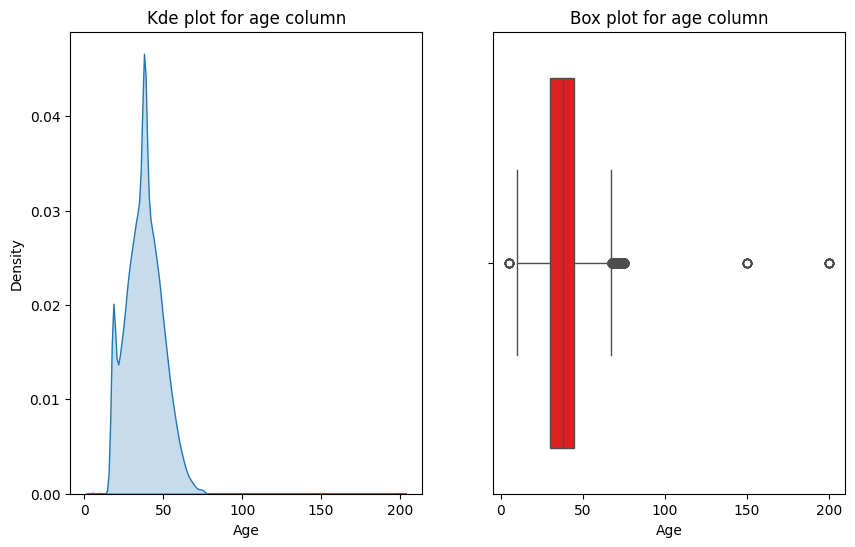

In [14]:
# Understanding the distribution for age column

fig, axes = plt.subplots(1,2, figsize = (10,6))

for ax in axes:
    sns.kdeplot(data = data, x = data['Age'], fill = True, ax = axes[0])
    axes[0].set_title('Kde plot for age column')
    sns.boxplot(data = data, x = data['Age'], orient = 'h', color = 'red', ax = axes[1])
    axes[1].set_title('Box plot for age column')
    plt.show()


In [15]:
# Statistical Summary
data['Age'].describe()

count    50000.000000
mean        37.812800
std         11.535688
min          5.000000
25%         30.000000
50%         38.000000
75%         45.000000
max        200.000000
Name: Age, dtype: float64

In [16]:
# No of outliers
q1 = data['Age'].quantile(0.25)
q3 = data['Age'].quantile(0.75)
iqr = q3-q1
lower_fence = q1-1.5*iqr
upper_fence = q3+1.5*iqr
lf_outliers = len(data[data['Age']<lower_fence])
uf_outliers = len(data[data['Age']>upper_fence])
print('Outliers below lower fence:', lf_outliers, '\nOutliers above upper fence:', uf_outliers)

Outliers below lower fence: 16 
Outliers above upper fence: 305


In [17]:
# Convert normal distribution to standard normal distribution

# Create the scaler: This creates the object that will calculate the mean and standard deviation
scaler = StandardScaler()

# Fit and transform the data: Transforms data using Z-score formula, 𝑍 = (𝑥 − 𝜇)/𝜎
data['scaled_age'] = scaler.fit_transform(data[['Age']])

# Scaled sample
data[['scaled_age']].head()

,scaled_age
0,0.449670
1,-0.157149
2,0.623047
3,1.576619
4,-0.243837


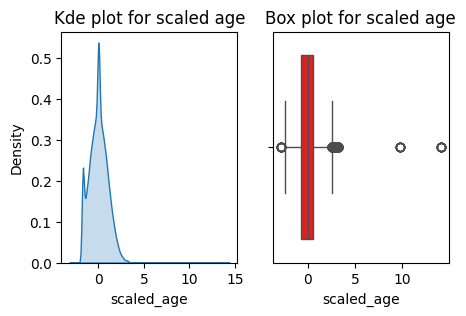

In [18]:
fig, axes = plt.subplots(1,2, figsize = (5,3))

for ax in axes:
    sns.kdeplot(data = data, x = data['scaled_age'], fill = True, ax = axes[0])
    axes[0].set_title('Kde plot for scaled age')
    sns.boxplot(data = data, x = data['scaled_age'], orient = 'h', color = 'red', ax = axes[1])
    axes[1].set_title('Box plot for scaled age')
    plt.show()

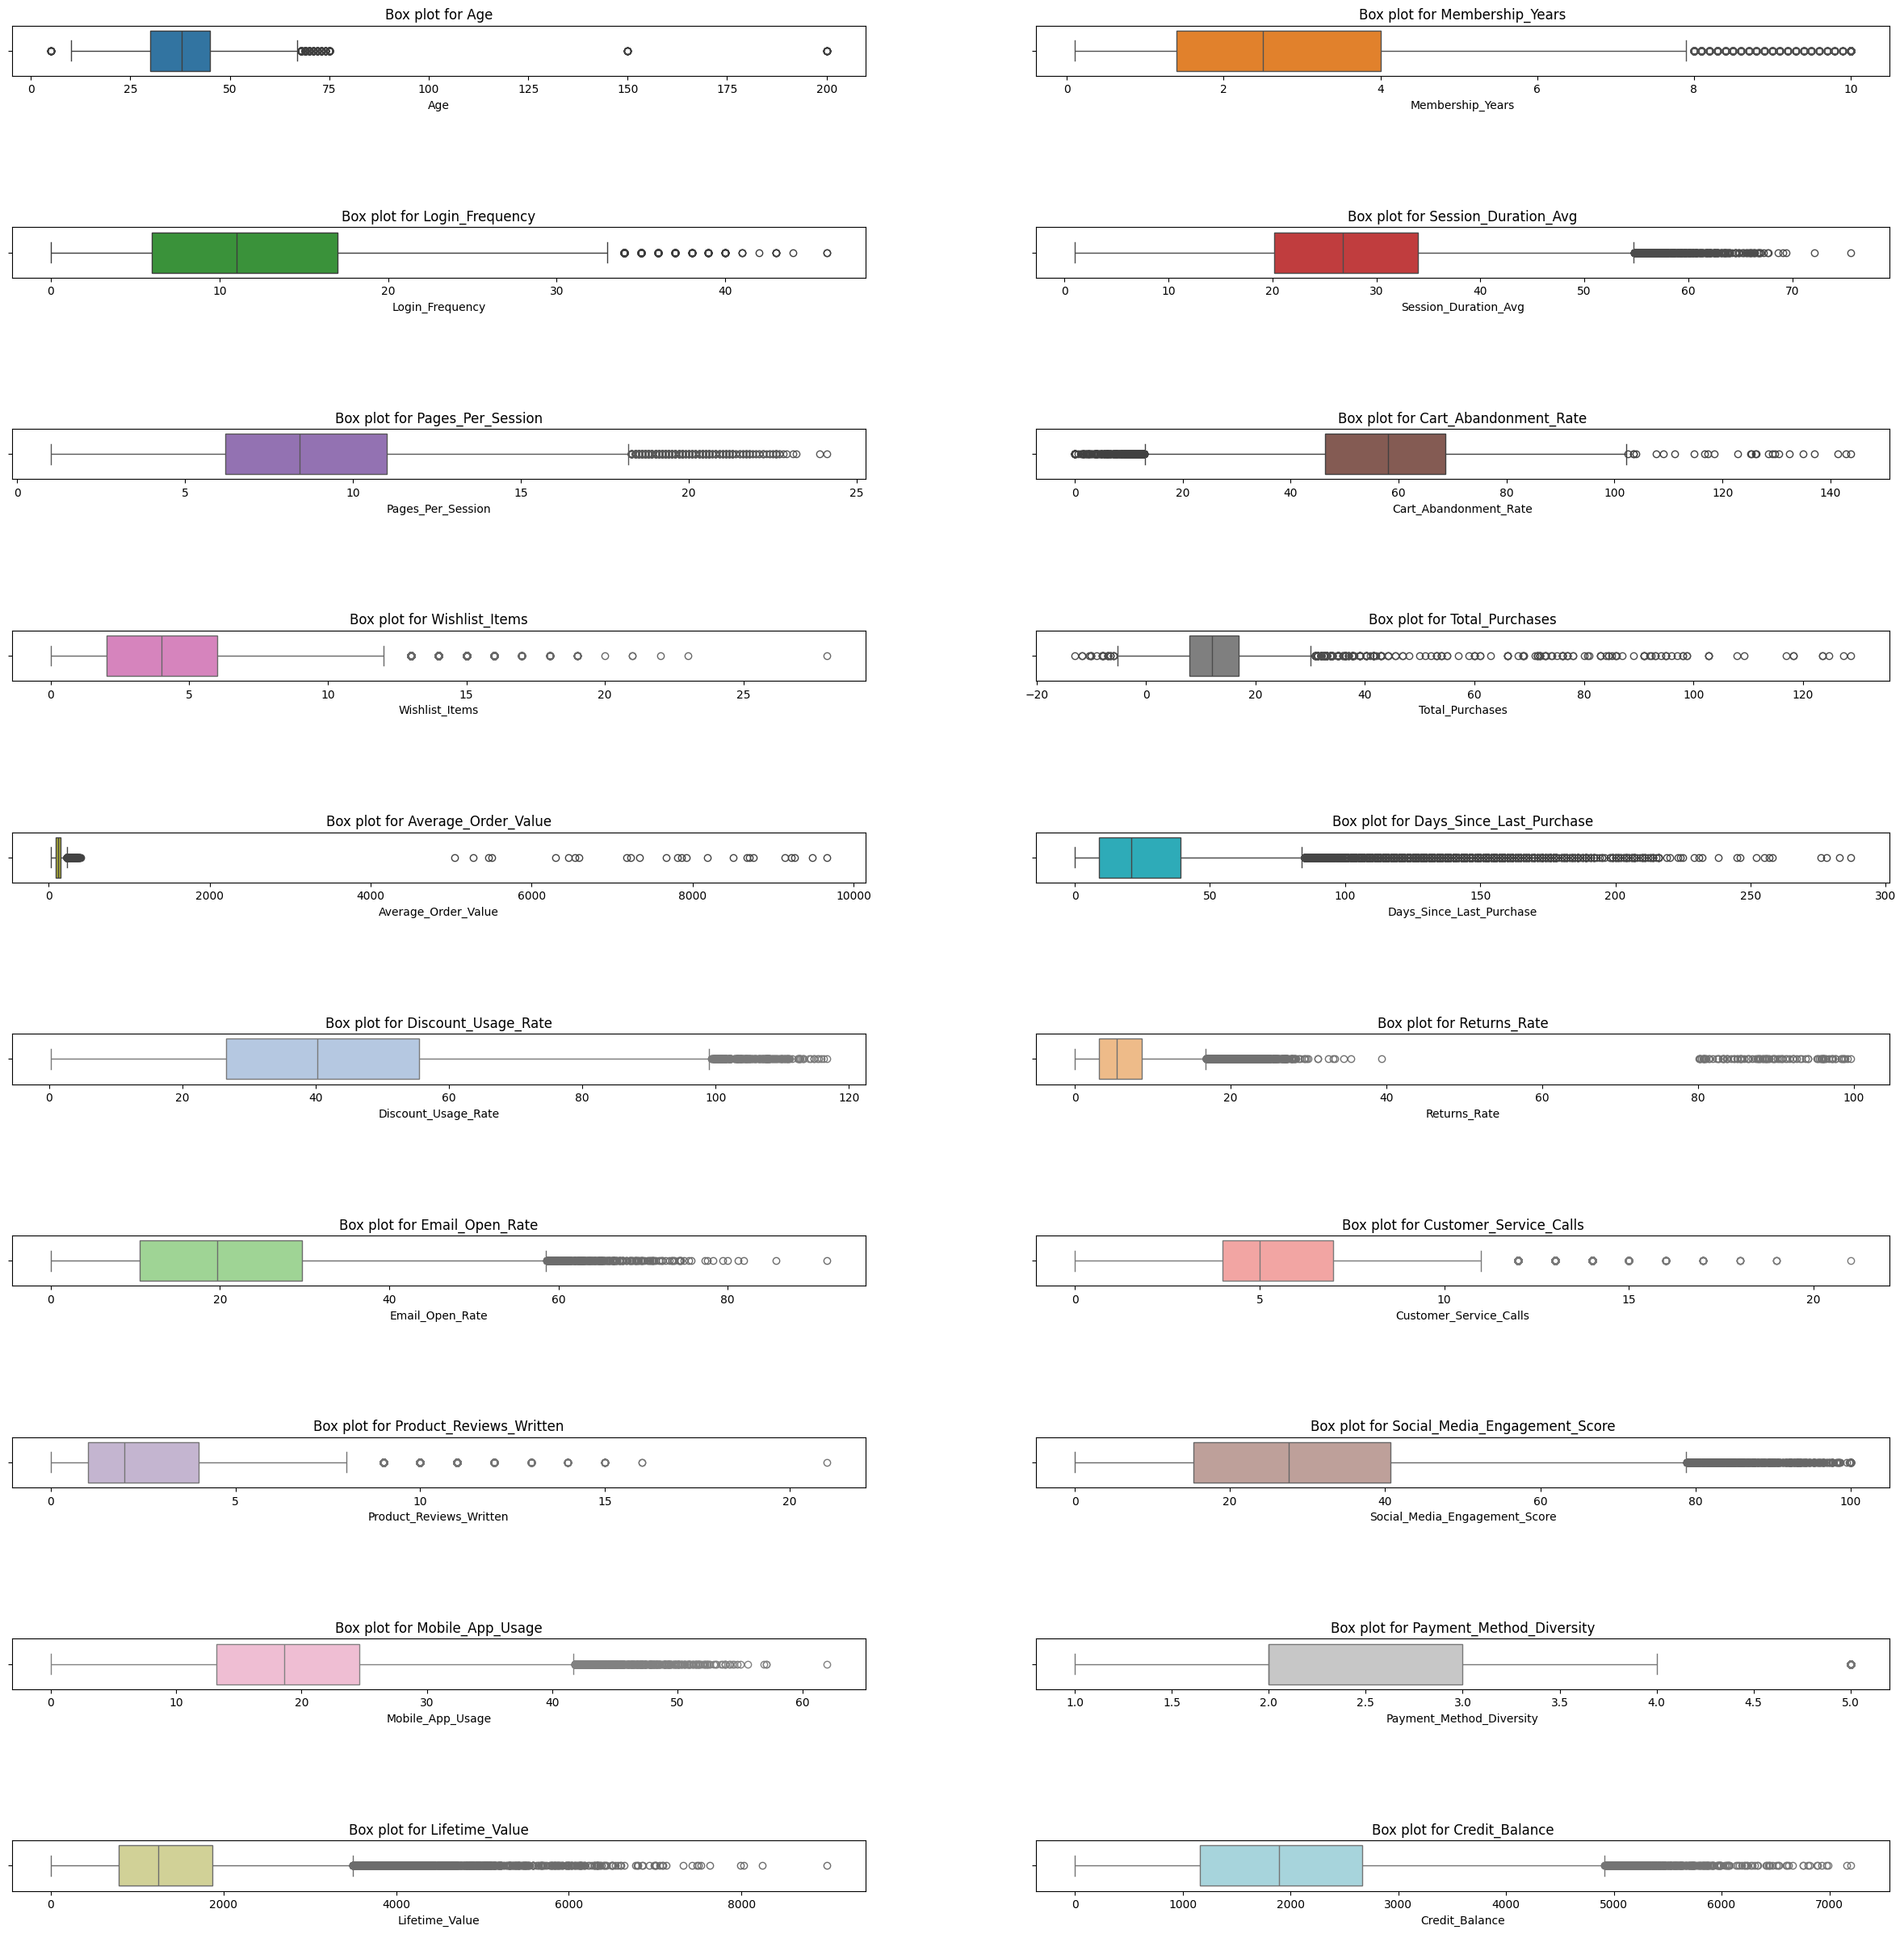

In [19]:
# Understanding the boxplot for other Numerical cols
fig, axes = plt.subplots(10, 2, figsize=(30,30))
plt.subplots_adjust(hspace=3)
axes = axes.flatten()

features = ['Age','Membership_Years',
 'Login_Frequency',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Average_Order_Value',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Lifetime_Value',
 'Credit_Balance',
 ]

colors = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#7f7f7f',  # gray
    '#bcbd22',  # olive
    '#17becf',  # teal
    '#aec7e8',  # light blue
    '#ffbb78',  # light orange
    '#98df8a',  # light green
    '#ff9896',  # light red
    '#c5b0d5',  # light purple
    '#c49c94',  # light brown
    '#f7b6d2',  # light pink
    '#c7c7c7',  # light gray
    '#dbdb8d',  # light olive
    '#9edae5'  # light teal

]


for ax, feature, color in zip(axes, features, colors):
    sns.boxplot(data = data, x = data[feature], orient = 'h', color = color, ax = ax)
    ax.set_title(f'Box plot for {feature}')
plt.show()

In [20]:
# No of outliers and skewness

features = ['Age','Membership_Years',
 'Login_Frequency',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Average_Order_Value',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Lifetime_Value',
 'Credit_Balance',
 ]

skew_groups = {
    "Left skewed": [],
    "Right skewed": [],
    "Both sides (heavy tails)": [],
    "Approximately symmetric": []
}

for feature in features:
    q1 = data[feature].quantile(0.25)
    q3 = data[feature].quantile(0.75)
    iqr = q3-q1
    lower_fence = q1-1.5*iqr
    upper_fence = q3+1.5*iqr
    lf_outliers = len(data[data[feature]<lower_fence])
    uf_outliers = len(data[data[feature]>upper_fence])

    if lf_outliers > 0 and uf_outliers == 0:
        skew = "Left skewed"
    elif uf_outliers > 0 and lf_outliers == 0:
        skew = "Right skewed"
    elif uf_outliers > 0 and lf_outliers > 0:
        skew = "Both sides (heavy tails)"
    else:
        skew = "Approximately symmetric"

    print(
    f"Feature: {feature}\n"
    f"Outliers below lower fence: {lf_outliers}\n"
    f"Outliers above upper fence: {uf_outliers}\n"
    f"Skewness (IQR-based): {skew}\n\n"
    )

# Checking skewness
    skew_groups[skew].append(feature)


# Skewed columns

for k, v in skew_groups.items():
    print(f"{k}: {v}\n")
    

Feature: Age
Outliers below lower fence: 16
Outliers above upper fence: 305
Skewness (IQR-based): Both sides (heavy tails)


Feature: Membership_Years
Outliers below lower fence: 0
Outliers above upper fence: 1581
Skewness (IQR-based): Right skewed


Feature: Login_Frequency
Outliers below lower fence: 0
Outliers above upper fence: 309
Skewness (IQR-based): Right skewed


Feature: Session_Duration_Avg
Outliers below lower fence: 0
Outliers above upper fence: 529
Skewness (IQR-based): Right skewed


Feature: Pages_Per_Session
Outliers below lower fence: 0
Outliers above upper fence: 478
Skewness (IQR-based): Right skewed


Feature: Cart_Abandonment_Rate
Outliers below lower fence: 297
Outliers above upper fence: 26
Skewness (IQR-based): Both sides (heavy tails)


Feature: Wishlist_Items
Outliers below lower fence: 0
Outliers above upper fence: 858
Skewness (IQR-based): Right skewed


Feature: Total_Purchases
Outliers below lower fence: 24
Outliers above upper fence: 604
Skewness (IQR-ba

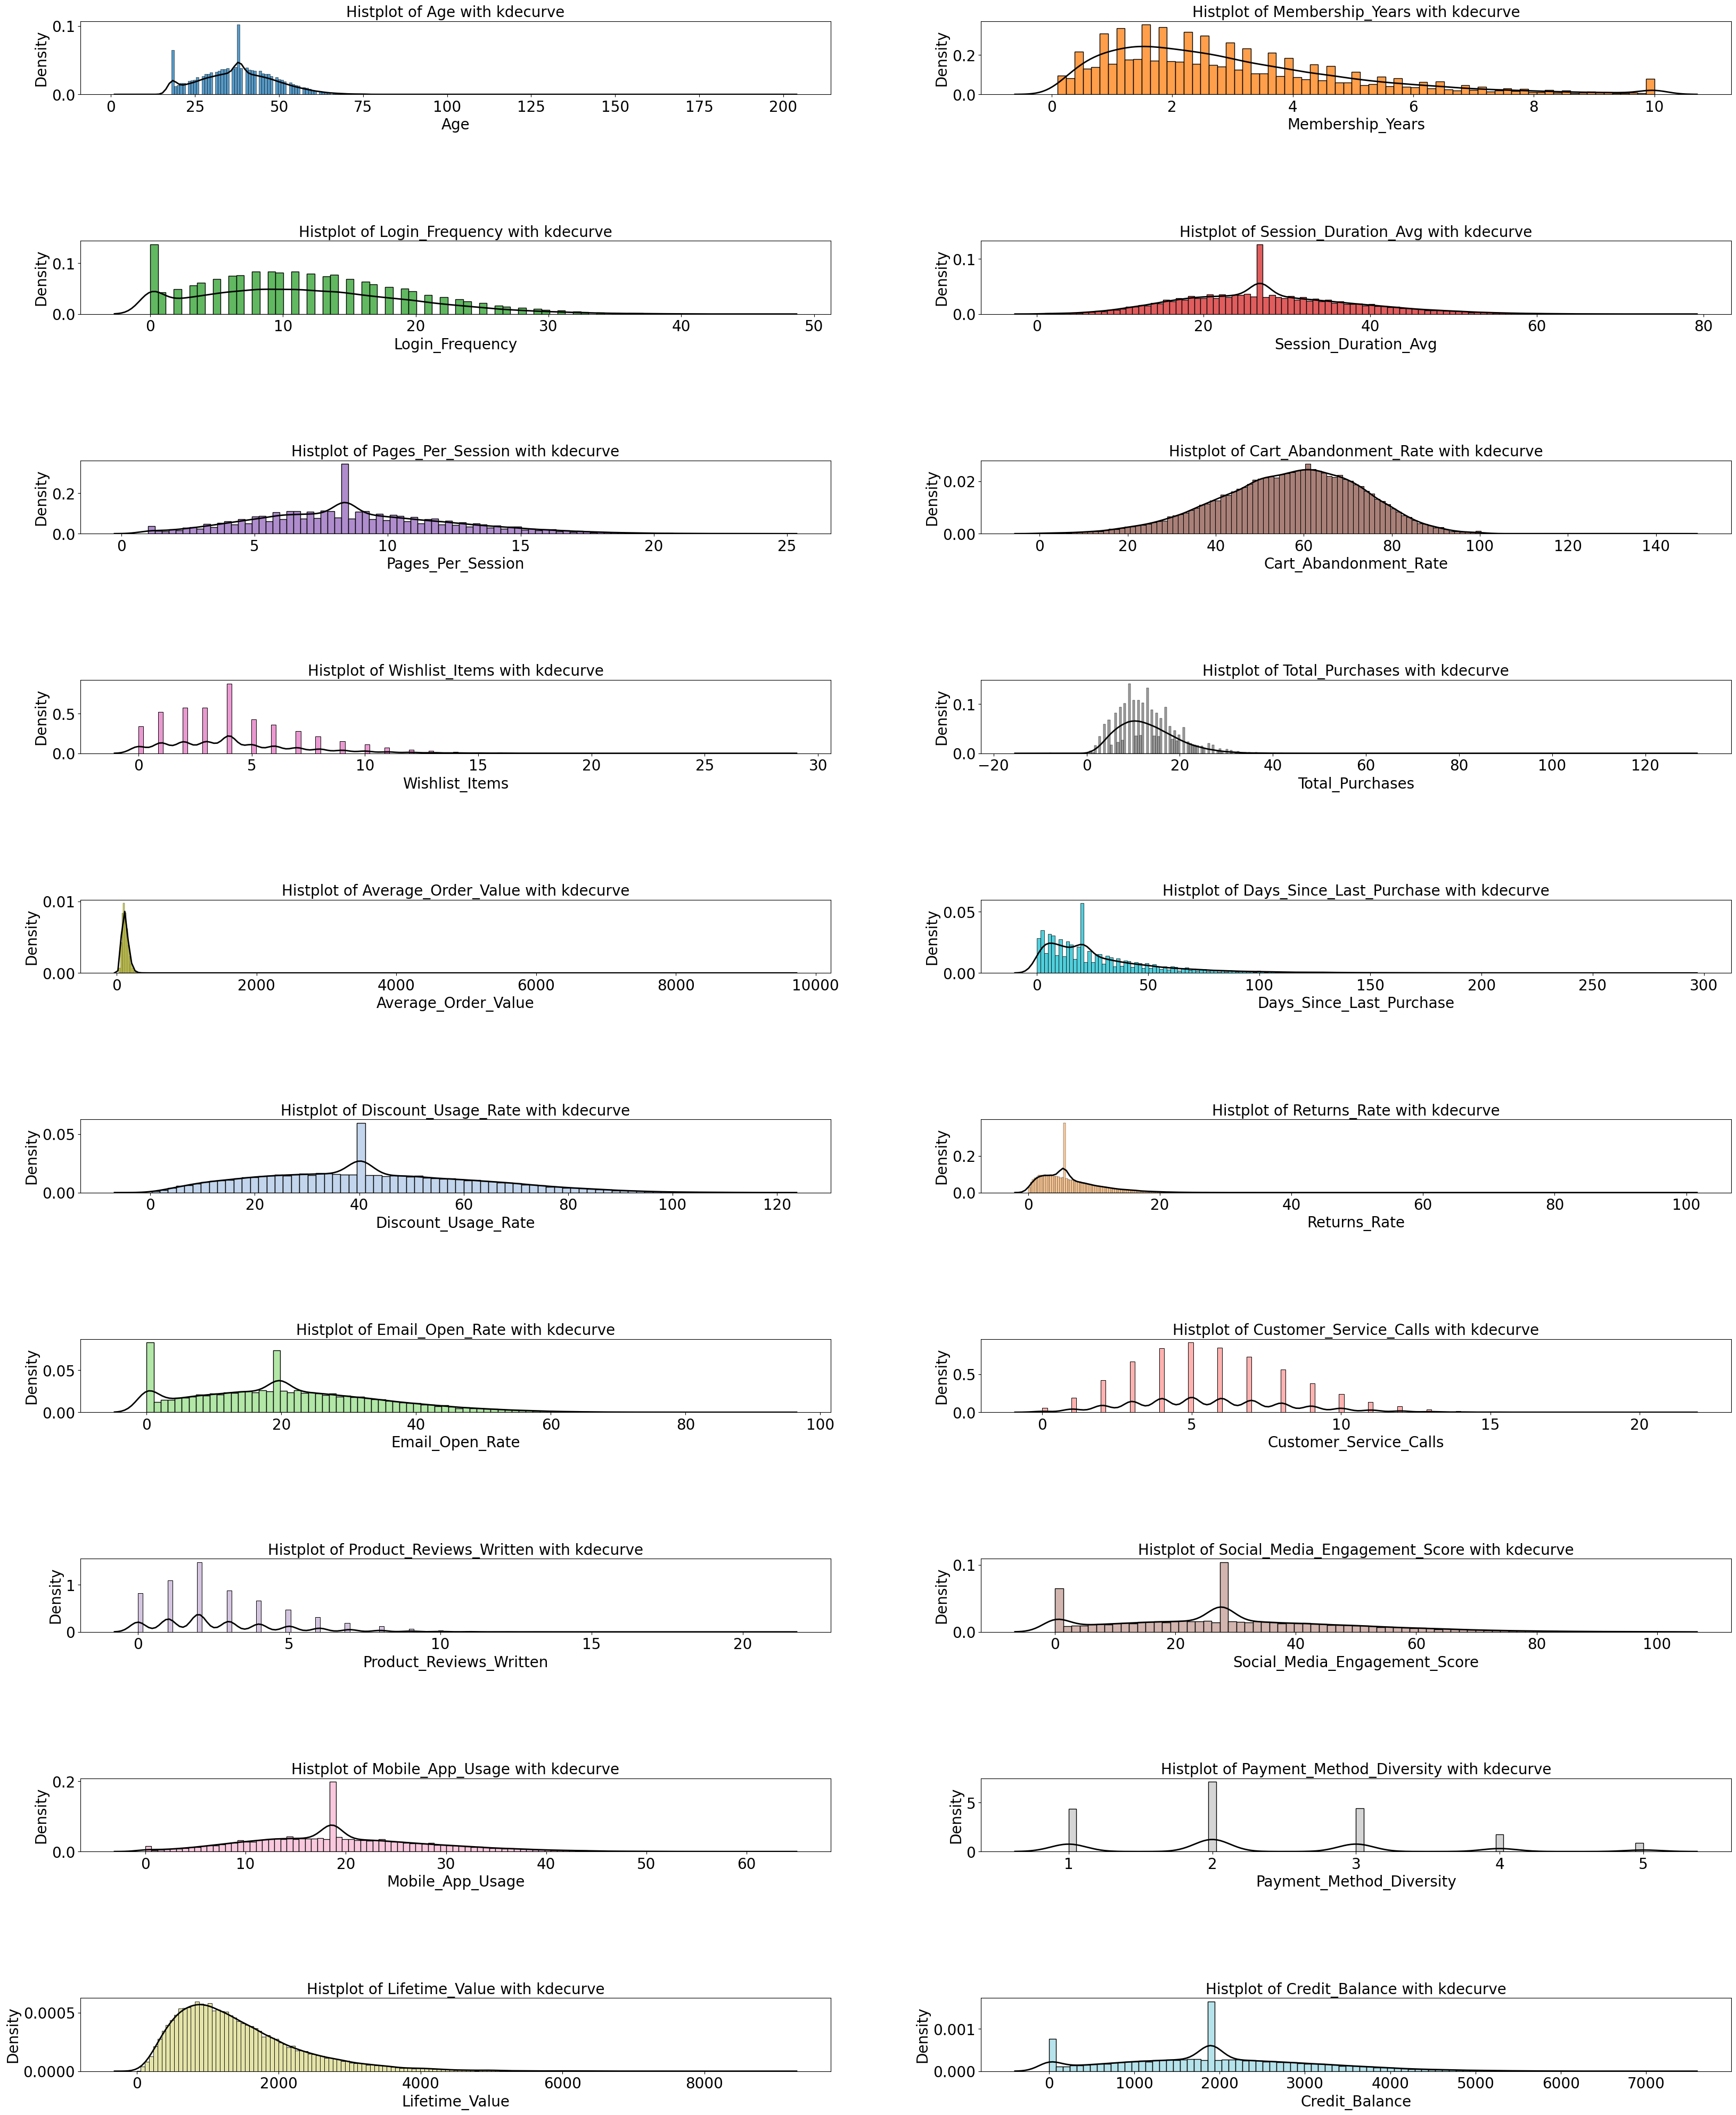

In [21]:

# Understanding the features with outliers using histogram
fig, axes = plt.subplots(10, 2, figsize=(40,50))
plt.subplots_adjust(hspace=2)
axes = axes.flatten()

features = ['Age','Membership_Years',
 'Login_Frequency',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Average_Order_Value',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Lifetime_Value',
 'Credit_Balance',
 ]

colors = [
    '#1f77b4',  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
    '#e377c2',  # pink
    '#7f7f7f',  # gray
    '#bcbd22',  # olive
    '#17becf',  # teal
    '#aec7e8',  # light blue
    '#ffbb78',  # light orange
    '#98df8a',  # light green
    '#ff9896',  # light red
    '#c5b0d5',  # light purple
    '#c49c94',  # light brown
    '#f7b6d2',  # light pink
    '#c7c7c7',  # light gray
    '#dbdb8d',  # light olive
    '#9edae5'  # light teal

]


#Loop through features and plot
for ax, feature, color in zip(axes, features, colors):
    
    #Histogram (normalized to density so KDE matches)
    sns.histplot(data[feature], stat="density", color=color, ax=ax, fill=True)
    
    #KDE curve (black line)
    sns.kdeplot(data[feature], color="black", ax=ax, linewidth=2)
    
    #Labels
    ax.set_title(f'Histplot of {feature} with kdecurve', fontsize=20)
    ax.set_xlabel(feature, fontsize=20)
    ax.set_ylabel('Density', fontsize=20)
    ax.tick_params(axis='both', labelsize=20)
plt.show()

### For Categorical Columns

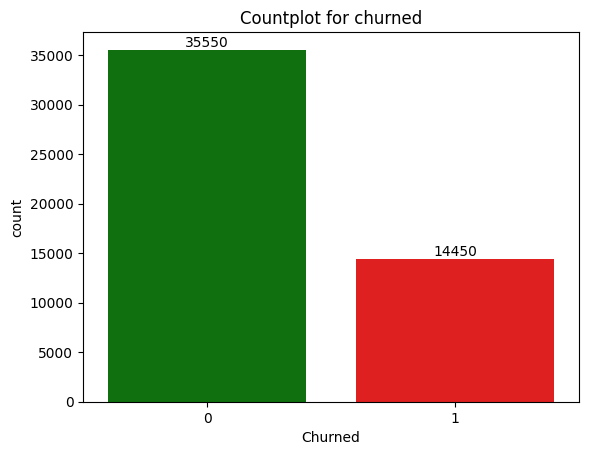

In [22]:
# Understanding Target Column

ax = sns.countplot(data = data, x = data['Churned'], order = data['Churned'].value_counts().index, palette = ['green', 'red'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title('Countplot for churned')
plt.show()


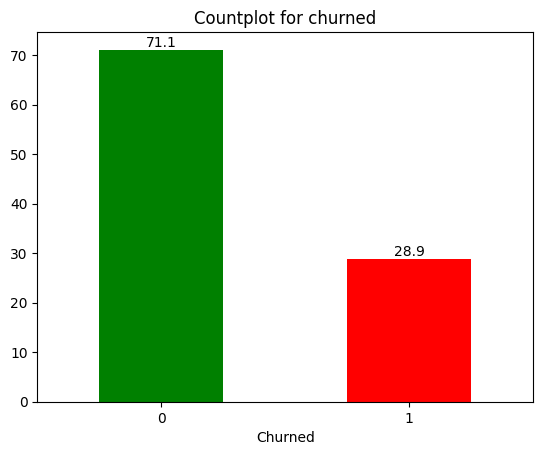

In [23]:
# Understanding Percentage of Target Column

ax = round(data['Churned'].value_counts(normalize=True)*100, 2).plot.bar(color = ['green', 'red'])
plt.xticks(rotation = 0)
ax.bar_label(ax.containers[0])
ax.set_title('Countplot for churned')
plt.show()


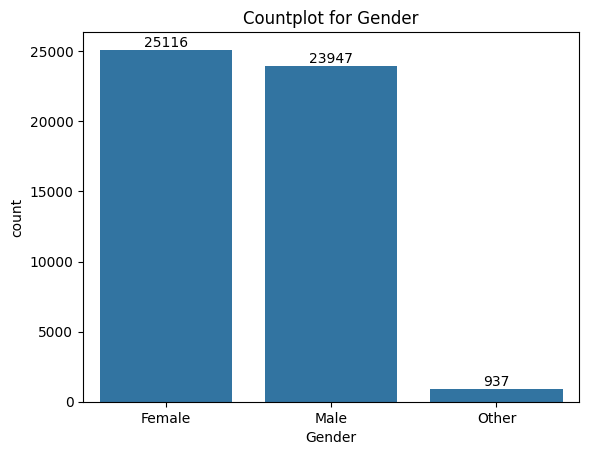

In [24]:
# Understanding the gender feature with countplot

ax = sns.countplot(data = data, x = data['Gender'], order = data['Gender'].value_counts().index)
ax.bar_label(ax.containers[0])
ax.set_title('Countplot for Gender')
plt.show()

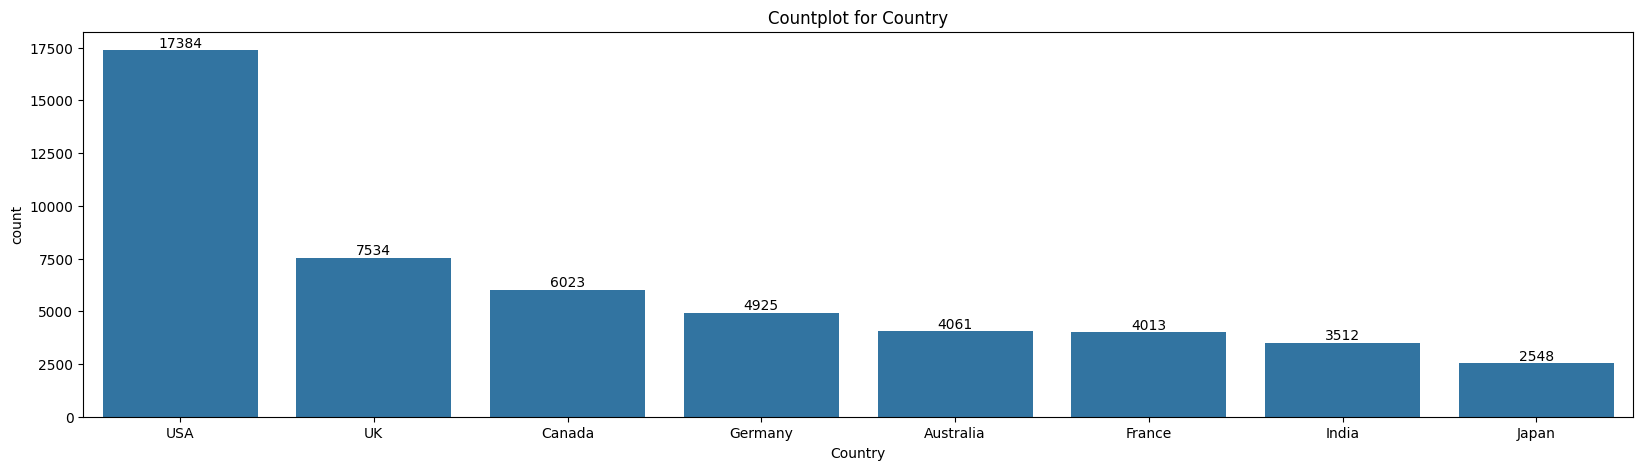

In [25]:
# Understanding the Country feature with countplot

plt.subplots(figsize=(20,5))
ax = sns.countplot(data = data, x = data['Country'], order = data['Country'].value_counts().index)
ax.bar_label(ax.containers[0])
ax.set_title('Countplot for Country')
plt.show()

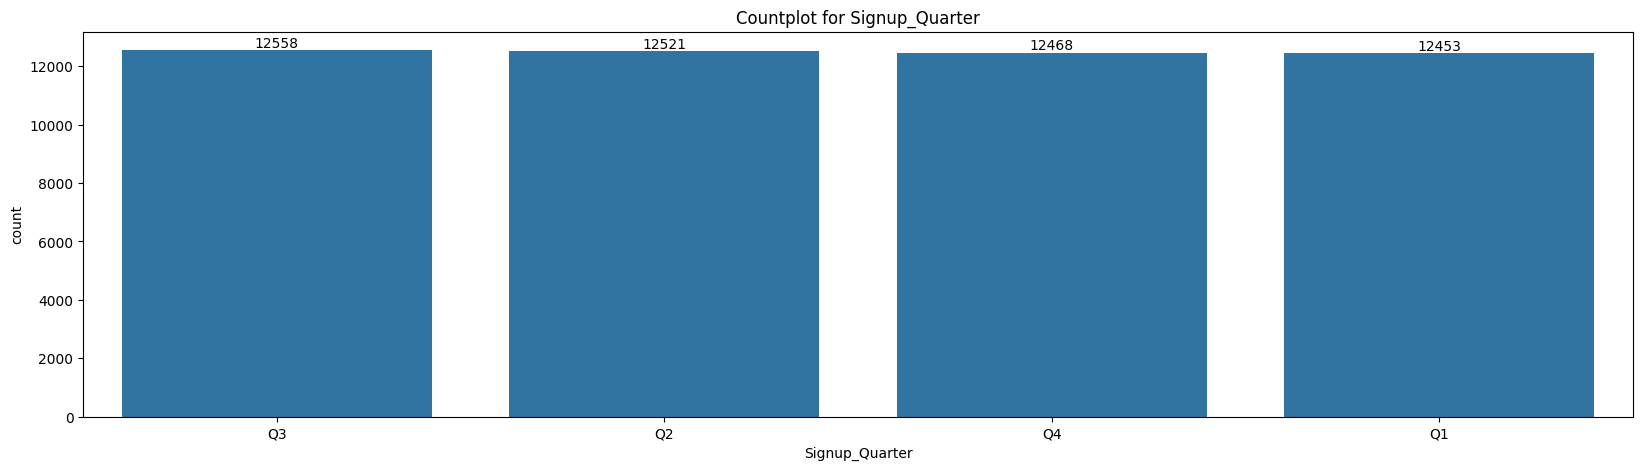

In [26]:
# Understanding the Signup_Quarter feature with countplot

plt.subplots(figsize=(20,5))
ax = sns.countplot(data = data, x = data['Signup_Quarter'], order = data['Signup_Quarter'].value_counts().index)
ax.bar_label(ax.containers[0])
ax.set_title('Countplot for Signup_Quarter')
plt.show()

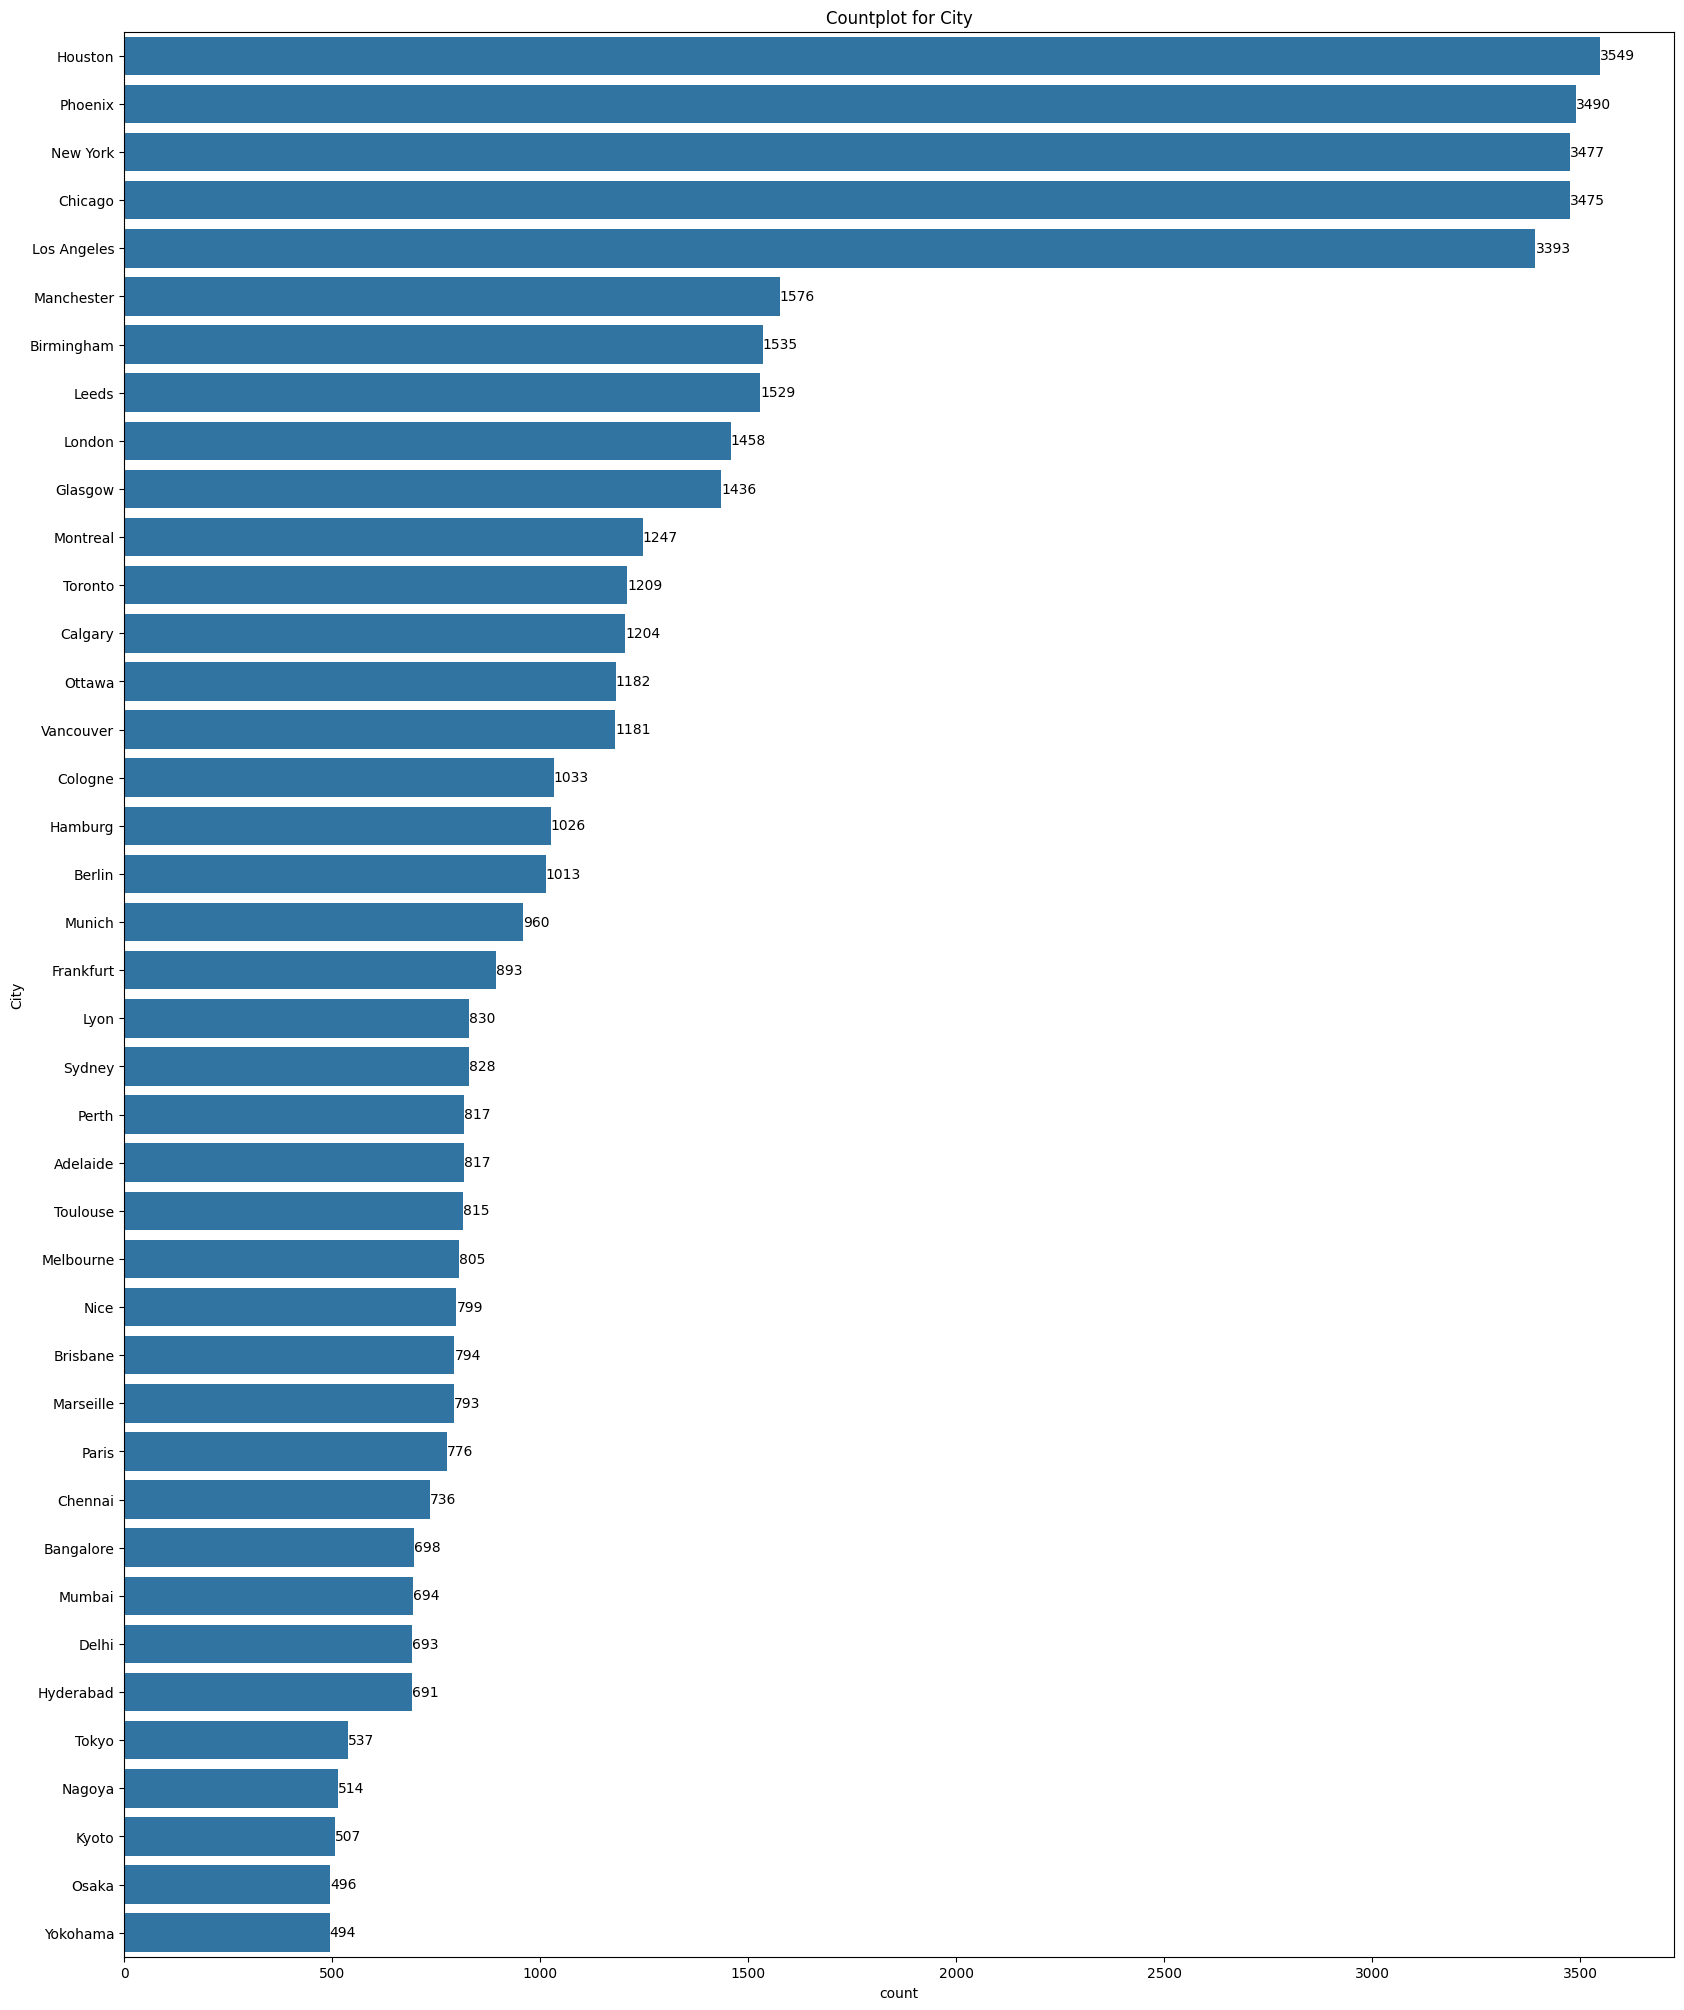

In [27]:
# Understanding the City feature with countplot

plt.subplots(figsize=(20,25))
ax = sns.countplot(data = data, y = data['City'], order = data['City'].value_counts().index)
ax.bar_label(ax.containers[0])
ax.set_title('Countplot for City')
plt.show()

### Observation 2 from Univariate Analysis

1. In numerical features 17 cols are highly right skewed and 3 cols are two tailed.
2. Target column churn has 35,550(71.1%) non-churned customers(28.9%) and 14,450 churned customers.
3. Females are prominent with 25,116 in number, followed by females with 23,947 and others are 937 in number.
4. Out of total 8 counties USA has most amount of customers i.e, 17384 and Japan has least amount of customers i.e, 2548.
5. Out of total 40 cities from all 8 countries, below are the top 5 cities and bottom 5 cities:
       
       Top 5 Cities: 
       Houston      :  3549
       Phoenix      :  3490
       New York     :  3477
       Chicago      :  3475
       Los Angeles  :  3393

       Bottom 5 Cities: 
       Tokyo        :   537
       Nagoya       :   514
       Kyoto        :   507
       Osaka        :   496
       Yokohama     :   494

## Bivariate Analysis

### Categorical v/s Categorical(Target)

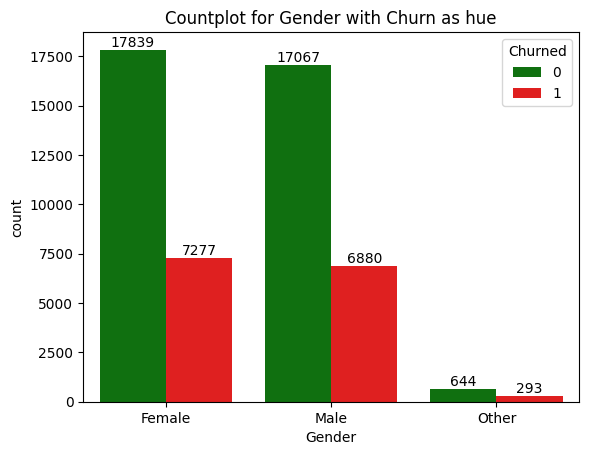

In [28]:
# Countplot of Gender with Churn as hue

fig, ax = plt.subplots()

sns.countplot(
    data=data,
    x="Gender",
    hue="Churned",
    order=data["Gender"].value_counts().index,
    palette=["green", "red"],
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container)

ax.set_title("Countplot for Gender with Churn as hue")
plt.show()

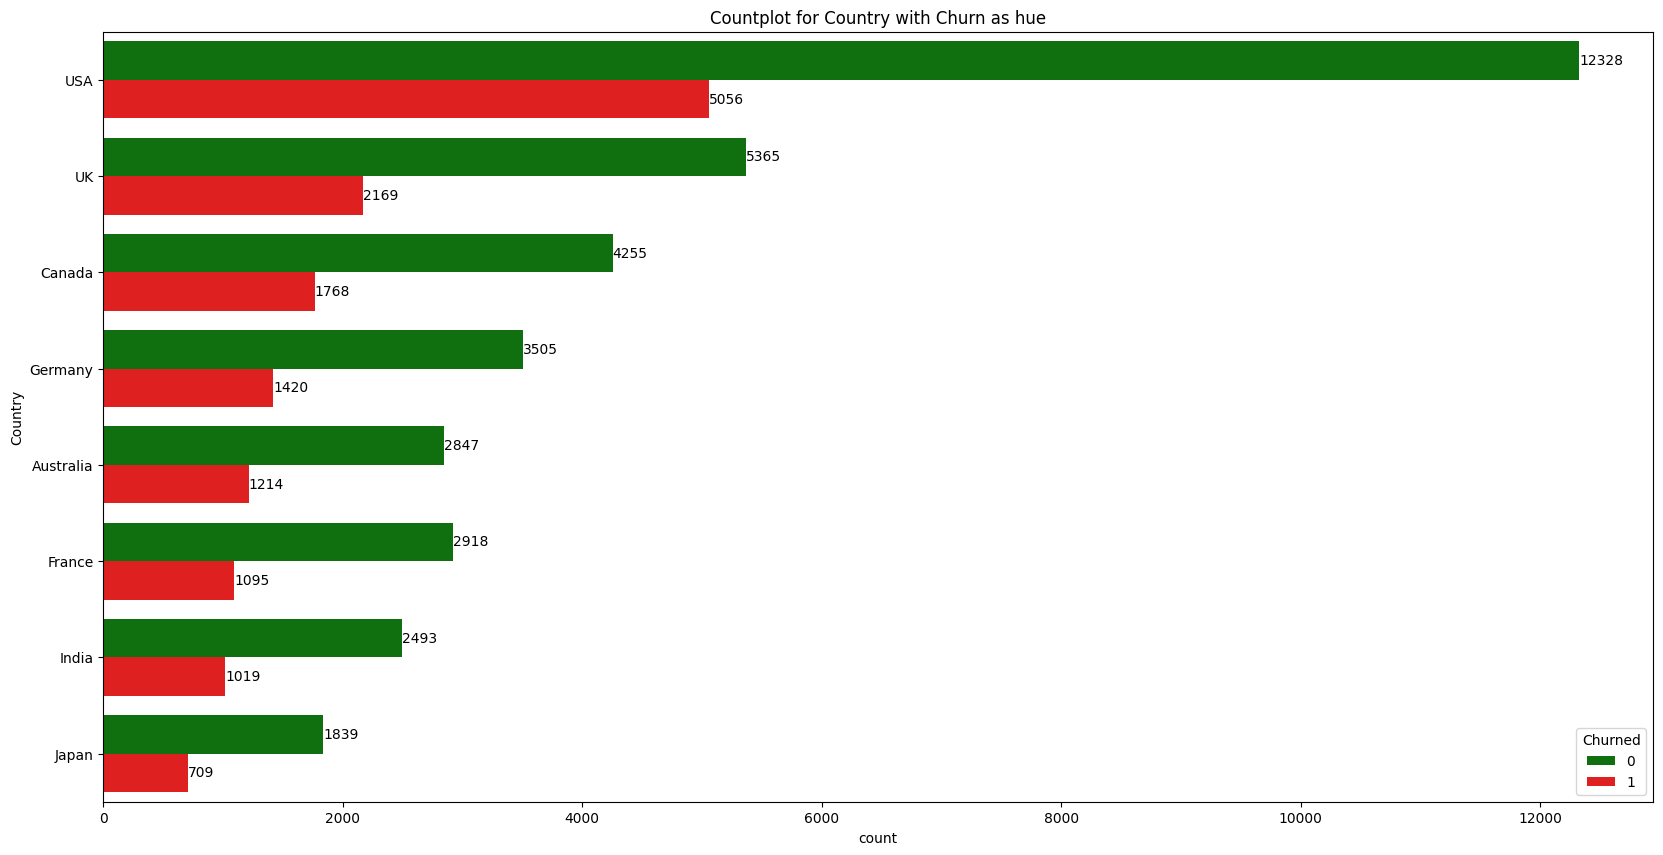

In [29]:
# Countplot of Country with Churn as hue

fig, ax = plt.subplots(figsize = (20, 10))

sns.countplot(
    data=data,
    y="Country",
    hue="Churned",
    order=data["Country"].value_counts().index,
    palette=["green", "red"],
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container)

ax.set_title("Countplot for Country with Churn as hue")
plt.show()

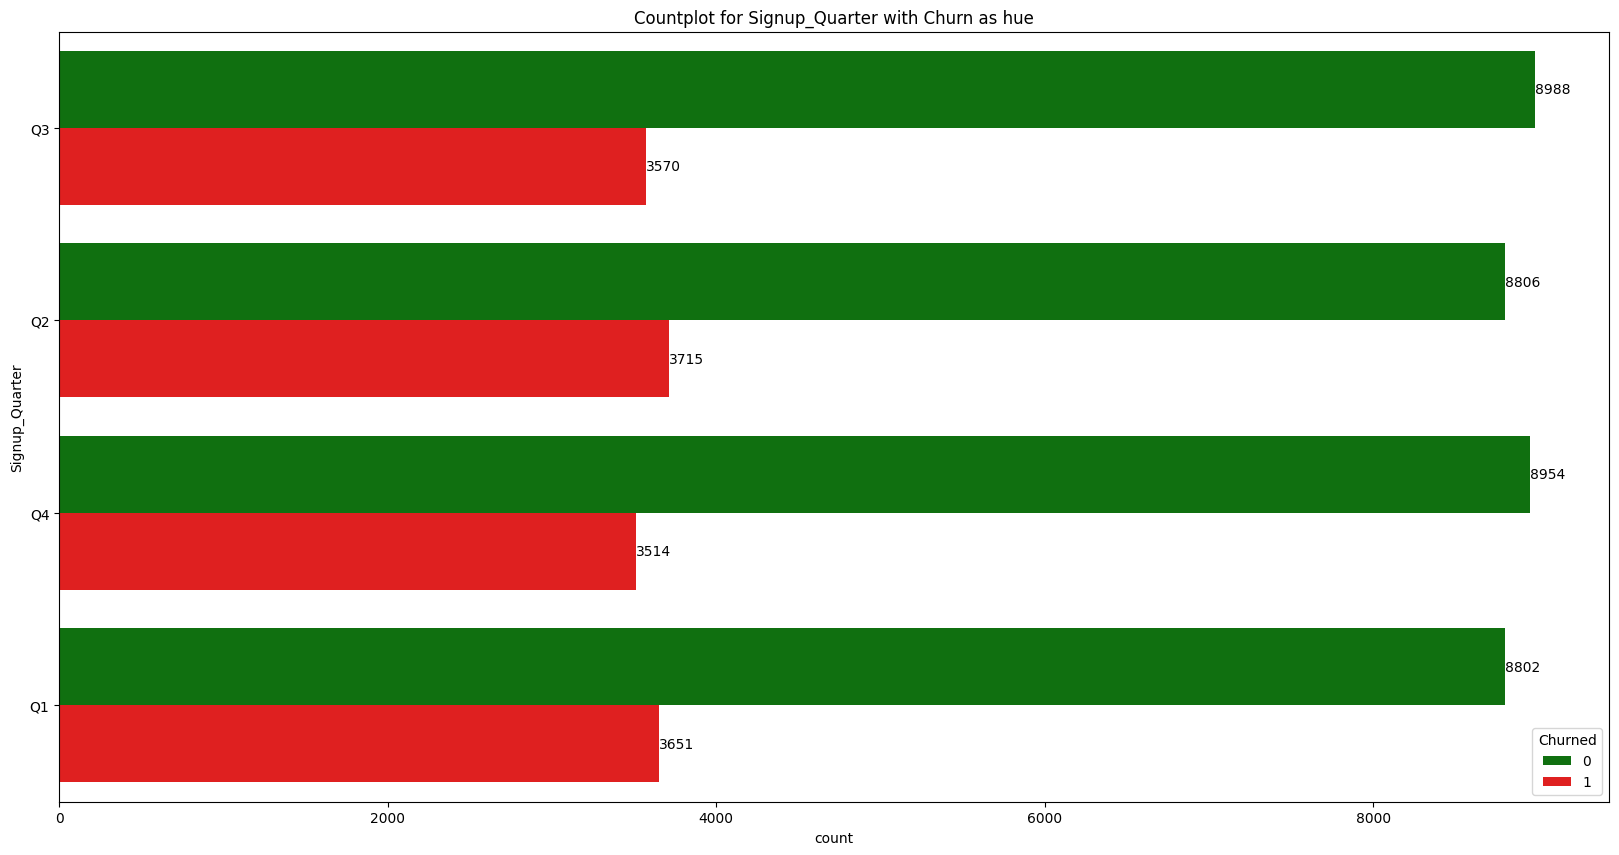

In [30]:
# Countplot of Signup_Quarter with Churn as hue

fig, ax = plt.subplots(figsize = (20, 10))

sns.countplot(
    data=data,
    y="Signup_Quarter",
    hue="Churned",
    order=data["Signup_Quarter"].value_counts().index,
    palette=["green", "red"],
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container)

ax.set_title("Countplot for Signup_Quarter with Churn as hue")
plt.show()

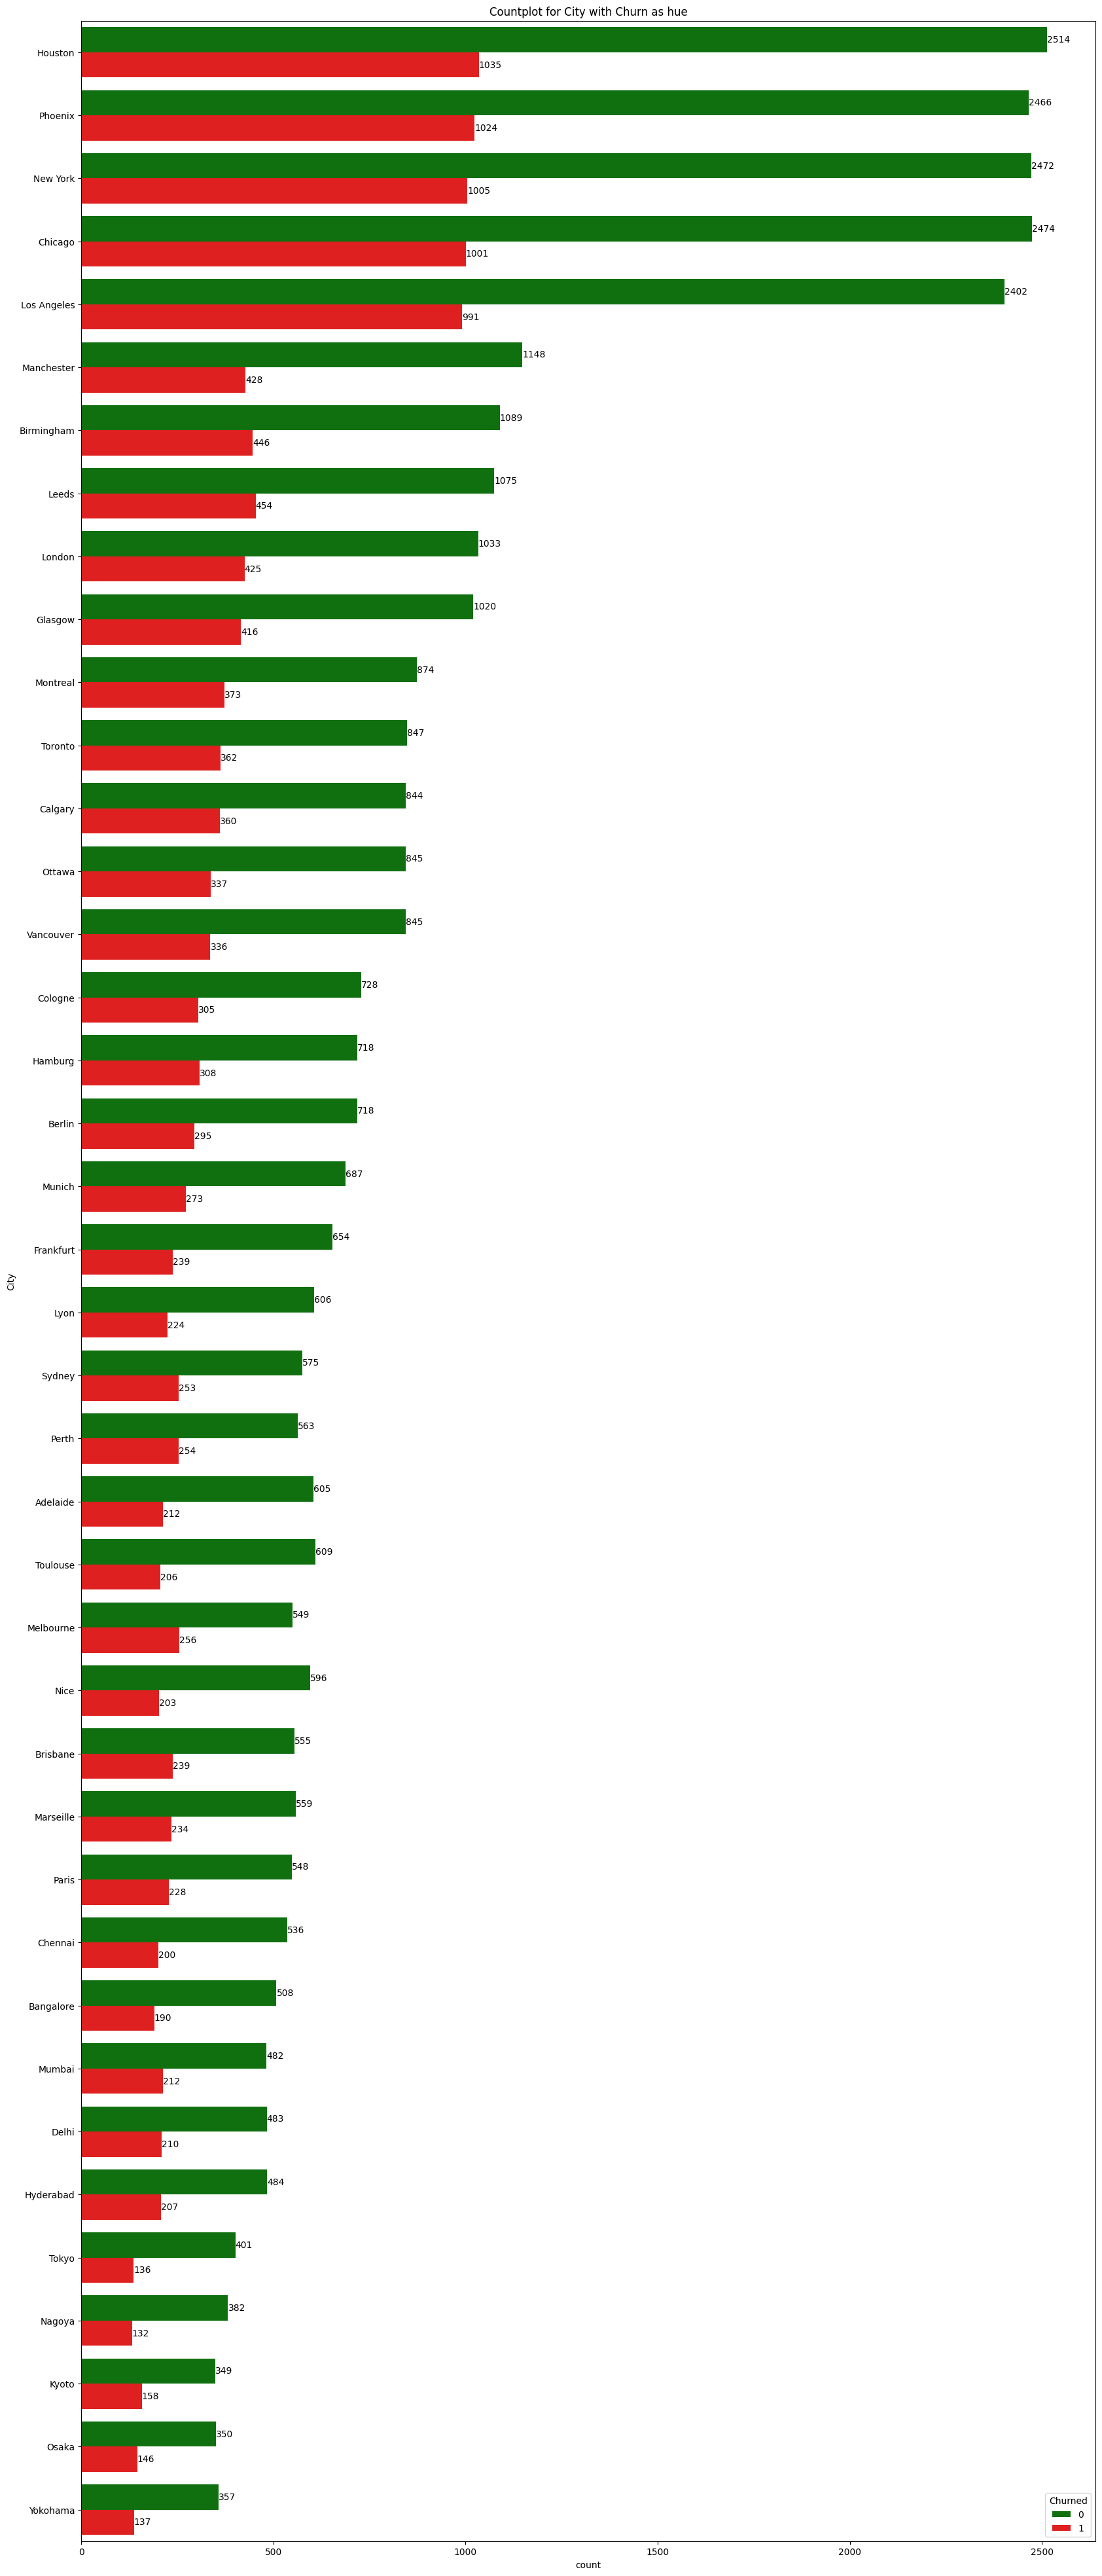

In [31]:
# Countplot of City with Churn as hue

fig, ax = plt.subplots(figsize = (20, 50))

sns.countplot(
    data=data,
    y="City",
    hue="Churned",
    order=data["City"].value_counts().index,
    palette=["green", "red"],
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container)

ax.set_title("Countplot for City with Churn as hue")
plt.show()

### Numerical v/s Categorical(Target)

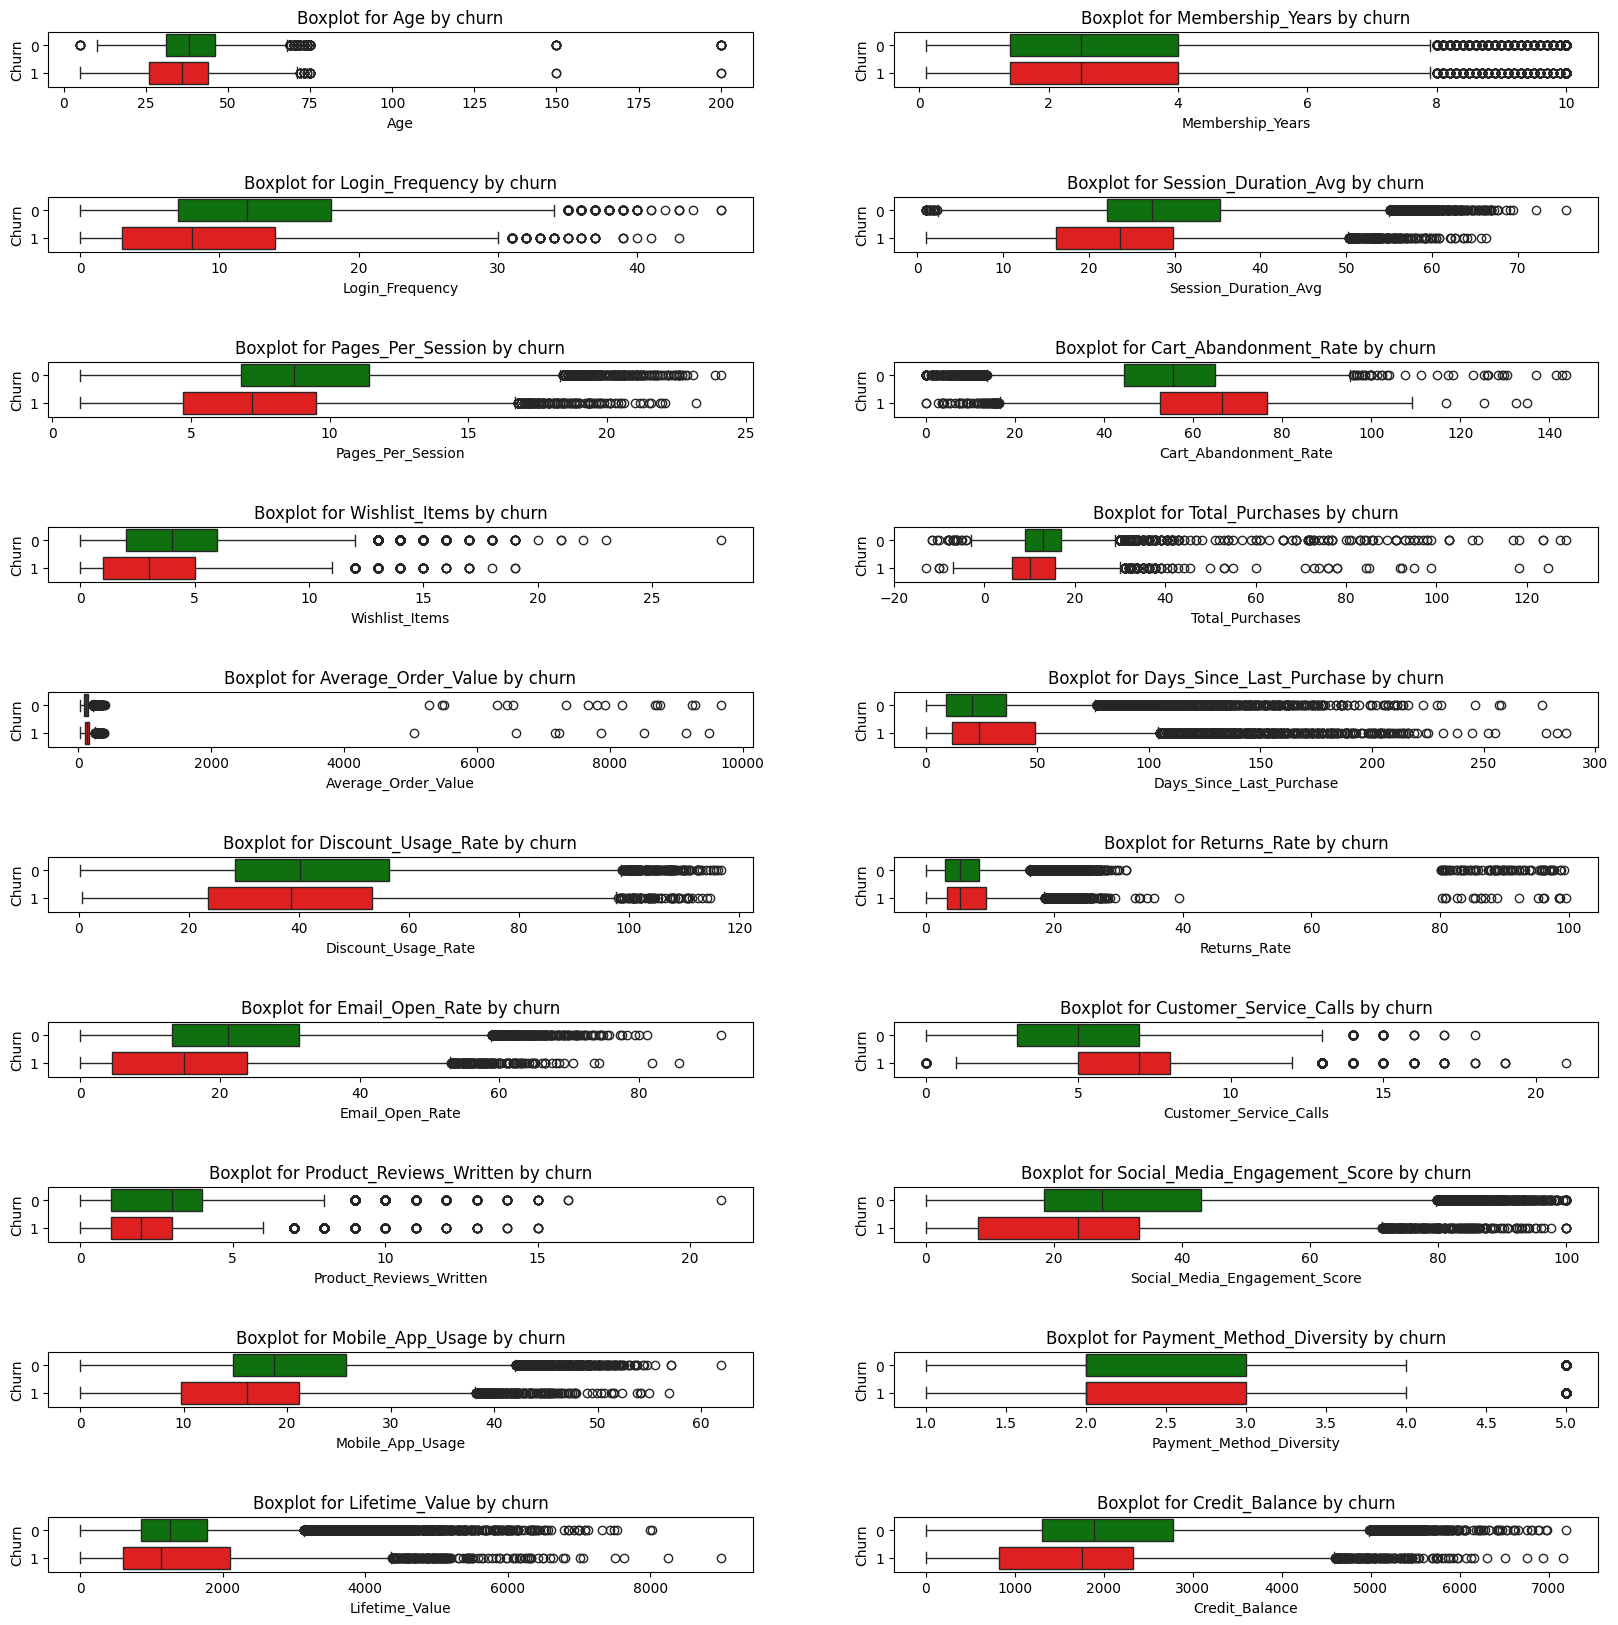

In [32]:
fig, axes = plt.subplots(10,2, figsize=(20, 20))
axes = axes.flatten()
plt.subplots_adjust(hspace = 2)

features = ['Age','Membership_Years',
 'Login_Frequency',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Average_Order_Value',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Lifetime_Value',
 'Credit_Balance',
 ]

for ax, feature in zip(axes, features):
    sns.boxplot(data = data, y = data['Churned'] , x = data[feature], ax=ax, palette = ['green', 'red'], orient = 'h')
    ax.set_title(f'Boxplot for {feature} by churn')
    ax.set_xlabel(feature)
    ax.set_ylabel('Churn')
plt.show()

### Numeric v/s Numeric

In [33]:
# Correlation between diff numeric columns
corr = data.drop(columns= ['scaled_age']).corr(numeric_only=True) # Not using churn col since it's a categorical column
corr

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
Age,1.000000,-0.004615,-0.004155,-0.001409,0.001133,0.000089,0.003655,-0.003946,-0.005474,0.000414,-0.000980,-0.011324,0.005482,0.001825,-0.001489,-0.001494,0.000479,0.001884,-0.001413,-0.004351,-0.100511
Membership_Years,-0.004615,1.000000,0.002305,0.006805,0.003577,-0.000698,0.005446,-0.022968,0.000680,-0.002569,0.005141,-0.036321,0.003734,-0.005245,0.004147,0.000289,0.002386,-0.005014,0.003583,0.007775,-0.000623
Login_Frequency,-0.004155,0.002305,1.000000,0.685319,0.654605,-0.624929,0.573833,0.588153,0.008432,0.003934,-0.002448,0.005459,0.583745,-0.372568,0.524043,0.547805,0.639903,0.005980,0.499324,0.476917,-0.204379
Session_Duration_Avg,-0.001409,0.006805,0.685319,1.000000,0.714086,-0.677323,0.628219,0.639808,0.001875,-0.000266,0.003006,0.002513,0.641172,-0.403278,0.570281,0.600677,0.698572,0.000825,0.541683,0.518605,-0.219512
Pages_Per_Session,0.001133,0.003577,0.654605,0.714086,1.000000,-0.648117,0.596167,0.606554,0.007157,0.001444,0.000573,0.000372,0.607967,-0.387198,0.543888,0.569395,0.665697,-0.001193,0.515333,0.495290,-0.224708
Cart_Abandonment_Rate,0.000089,-0.000698,-0.624929,-0.677323,-0.648117,1.000000,-0.570538,-0.576277,-0.004015,-0.004515,-0.000759,-0.001298,-0.576144,0.369062,-0.517351,-0.543365,-0.635456,0.000941,-0.495295,-0.469764,0.277963
Wishlist_Items,0.003655,0.005446,0.573833,0.628219,0.596167,-0.570538,1.000000,0.538305,-0.002173,0.003877,-0.000443,0.002436,0.539019,-0.336641,0.474566,0.499646,0.585203,0.000763,0.458572,0.433586,-0.189569
Total_Purchases,-0.003946,-0.022968,0.588153,0.639808,0.606554,-0.576277,0.538305,1.000000,0.003306,0.009253,0.036568,0.273638,0.542336,-0.344430,0.483044,0.510468,0.590560,0.005130,0.622778,0.440497,-0.160029
Average_Order_Value,-0.005474,0.000680,0.008432,0.001875,0.007157,-0.004015,-0.002173,0.003306,1.000000,-0.000140,-0.000326,0.000363,-0.002741,-0.000861,0.001081,0.000750,0.000557,0.002526,0.151574,0.006705,0.042288
Days_Since_Last_Purchase,0.000414,-0.002569,0.003934,-0.000266,0.001444,-0.004515,0.003877,0.009253,-0.000140,1.000000,0.001483,0.004562,0.002112,-0.004774,0.006377,0.001396,0.002082,0.001572,0.006921,0.002762,0.148015


In [34]:
# Filtering float values
float_cols = data.columns[data.dtypes == float].tolist()
float_cols

['Age',
 'Membership_Years',
 'Login_Frequency',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Average_Order_Value',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Lifetime_Value',
 'Credit_Balance',
 'scaled_age']

In [35]:
# Converting float cols to int

data[float_cols] = data[float_cols].astype('int8')

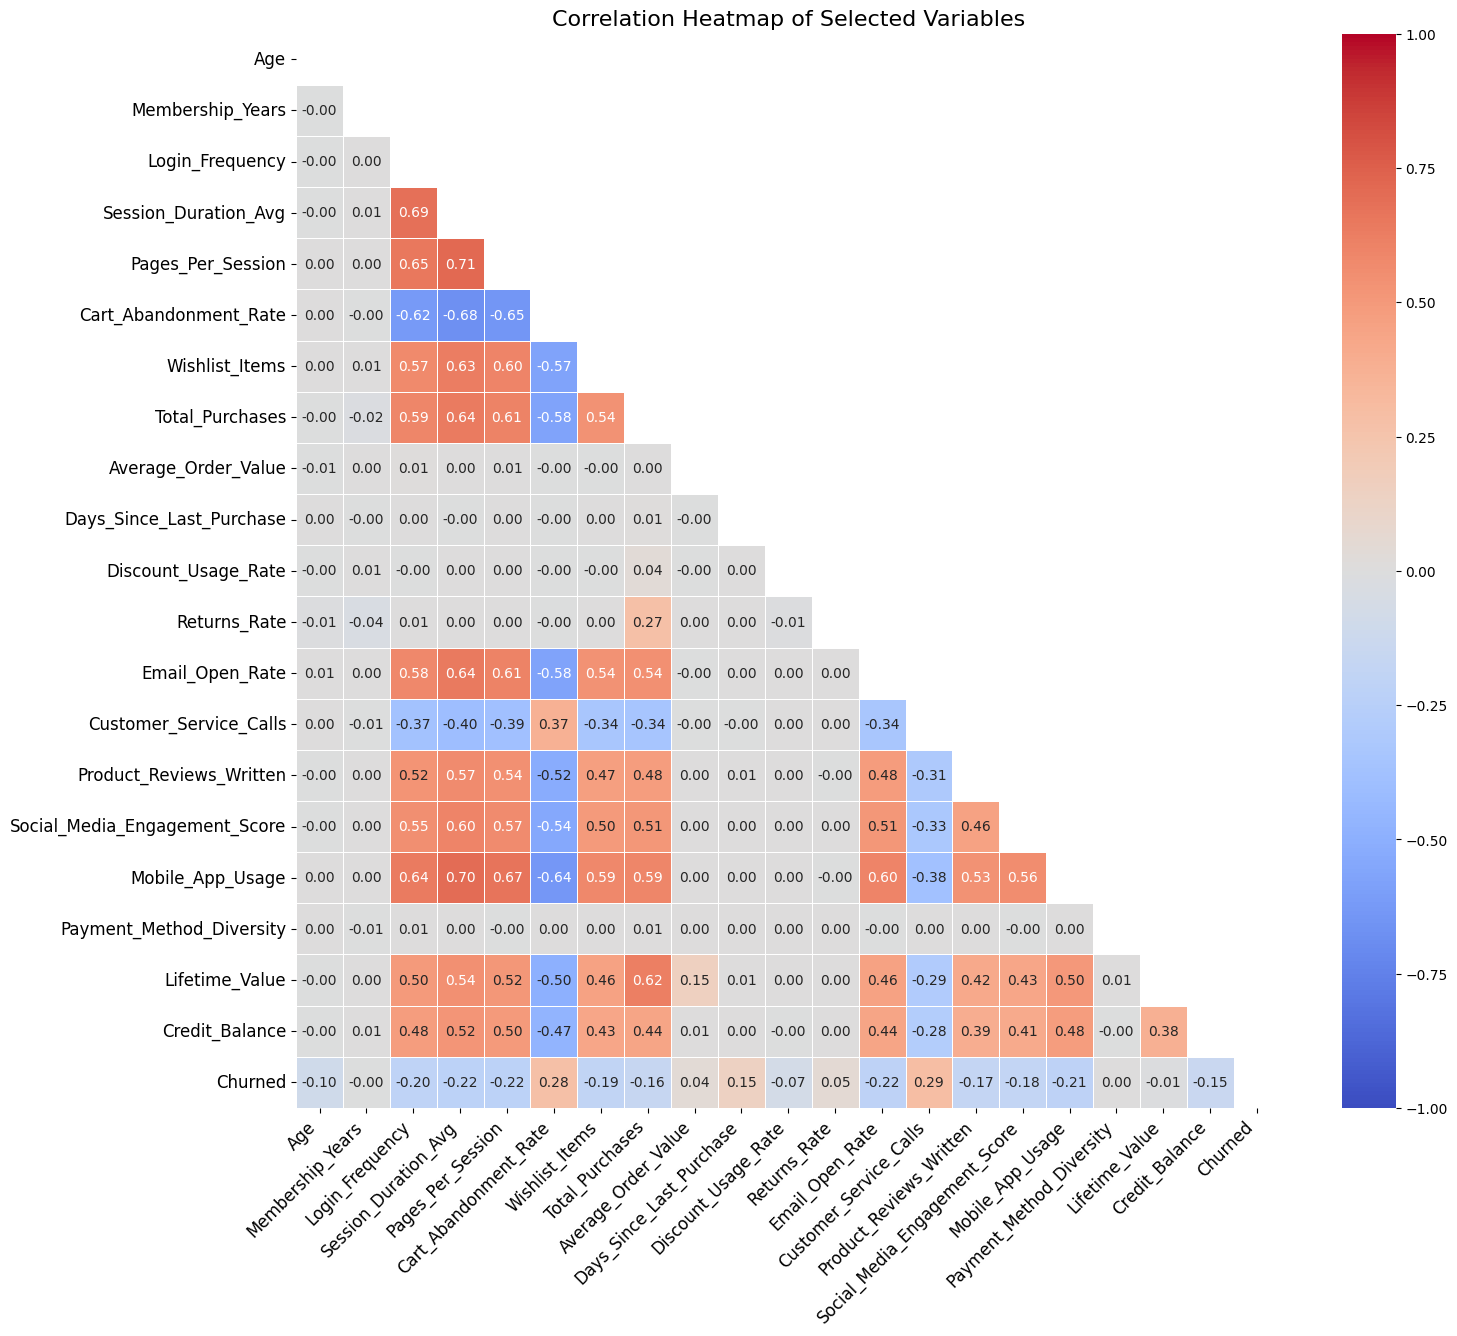

In [36]:
# Improved heatmap for better visibility
plt.figure(figsize=(16, 14))

# Create a mask for the upper triangle
mask = np.triu(corr)

# Enhanced heatmap
sns.heatmap(
    corr,
    annot=True,               # Show correlation values
    fmt=".2f",                # Format to 2 decimal places
    cmap='coolwarm',          # Alternative high-contrast colormap
    vmin=-1, vmax=1,          # Full correlation range
    mask=mask,                # Hide upper triangle
    linewidths=0.5,           # Add cell borders
)

plt.title('Correlation Heatmap of Selected Variables', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)  # Larger x labels
plt.yticks(fontsize=12)  # Larger y labels

# Save the figure as PNG with high resolution
plt.savefig('numerical_features_correlation.png', dpi=300, bbox_inches='tight')

# Adjust layout
plt.tight_layout(pad=3)
plt.show()

### Observation 3 from Bivariate Analysis

### Categorical v/s Categorical(Target) analysis

1. Out of total females around 28.97% churn out, 28.73% churn out of total males, and 31.27% peopl churn out, whose gender's are unspecified.
2.  All countries churnout rate is between 27-29%. 
3. Quarter churn out is 29-30% for all quarters.
4. City churnout is between 25-32% with cities from Australia topping in the list.


### Numerical v/s Categorical(Target) analysis


### Engagement Metrics

**Login_Frequency**  
Retained users have a mean login frequency of **12.64** (median: **12**), whereas churned users show a lower mean of **9.12** (median: **8**). This represents a reduction of approximately **28%** among churned customers, indicating that declining platform usage is a strong early signal of churn.

**Session_Duration_Avg**  
The average session duration for retained users is **28.60 minutes** (median: **27**), compared to **23.50 minutes** (median: **23**) for churned users. The observed **18% decrease** suggests reduced engagement depth prior to churn.

**Pages_Per_Session**  
Retained users view an average of **8.80 pages per session** (median: **8**), while churned users view **6.99 pages** (median: **7**). This **21% decline** reflects shallower browsing behavior among churned customers.

**Email_Open_Rate**  
Retained users have a mean email open rate of **22.35%** (median: **21%**), whereas churned users average **15.76%** (median: **14%**). The **~6.6 percentage point difference** highlights early disengagement from marketing communications.

**Social_Media_Engagement_Score**  
The mean engagement score for retained users is **30.92**, compared to **23.30** for churned users. This **~25% lower engagement** suggests weaker brand affinity among churned customers.

**Mobile_App_Usage**  
Retained users show a mean mobile app usage of **20.04** (median: **18**), while churned users average **15.87** (median: **16**). The reduction of approximately **21%** indicates that frequent app usage is associated with higher retention.

---

### Purchase and Recency Behavior

**Days_Since_Last_Purchase**  
Retained users last purchased products **24.49 days ago** on average (median: **20**), whereas churned users show a longer inactivity period of **29.11 days** (median: **22**). This gap of **~4–5 days** reinforces recency as a key churn driver.

**Cart_Abandonment_Rate**  
The mean cart abandonment rate for retained users is **53.69%** (median: **55%**), compared to **63.69%** (median: **66%**) for churned users. The **10 percentage point increase** indicates higher purchase friction among churned customers.

**Total_Purchases**  
Retained users have made an average of **13.71 purchases** (median: **13**), while churned users average **11.24 purchases** (median: **10**). Although churned users purchase less, the overlap suggests this feature is more informative when combined with recency metrics.

**Wishlist_Items**  
Retained users maintain an average of **4.64 wishlist items** (median: **4**), compared to **3.36 items** (median: **3**) for churned users. Lower wishlist activity reflects reduced future purchase intent.

---

### Customer Interaction and Feedback

**Customer_Service_Calls**  
Retained users make an average of **5.18 service calls** (median: **5**), whereas churned users make **6.90 calls** (median: **7**). The **~33% increase** suggests unresolved issues and dissatisfaction contribute significantly to churn.

**Product_Reviews_Written**  
Retained users write an average of **3.04 reviews** (median: **3**), while churned users write **2.18 reviews** (median: **2**). Lower review activity indicates reduced emotional investment in the platform.

**Returns_Rate**  
The mean returns rate is **5.93%** for retained users and **6.60%** for churned users. The modest difference suggests returns play a secondary role in churn behavior.

---

### Weak or Non-Discriminative Features

**Age**  
Retained users have a mean age of **38.44 years**, compared to **35.92 years** for churned users. Given the large variance, age exhibits limited discriminatory power.

**Membership_Years**  
Both retained and churned users show nearly identical average tenure (**~2.54 years**), indicating that tenure alone does not explain churn.

**Payment_Method_Diversity**  
The average number of payment methods used is **2.33** for retained users and **2.34** for churned users, showing no meaningful separation.

**Discount_Usage_Rate**  
Retained users use discounts at **42.41%**, while churned users average **39.03%**. The inconsistent difference suggests discount usage influences purchasing behavior more than retention.

**Lifetime_Value and Credit_Balance**  
Both metrics exhibit nearly identical central tendencies between retained and churned users. As cumulative financial indicators, they capture customer value but are weak predictors of churn propensity.

---

### Data Quality Observations

Several numerical features contain **invalid negative values**, including:
- Age  
- Cart_Abandonment_Rate  
- Total_Purchases  
- Average_Order_Value  
- Lifetime_Value  
- Credit_Balance  

These values are not realistic in a business context and must be addressed during data cleaning prior to modeling.

---

### Summary

The analysis indicates that **churn is primarily driven by declining engagement, increasing inactivity, and higher friction**, rather than demographic characteristics or payment behavior. Engagement and recency metrics consistently show the strongest separation between retained and churned users and should be prioritized in downstream modeling.


### Numerical v/s Numerical analysis

#### Engagement Cluster (Very Strong Relationships)

| Cluster Name                    | Features in Cluster                                                  | Key Correlation Metrics                                                                                                                                    |
| ------------------------------- | -------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Engagement Intensity**        | Login_Frequency<br>Session_Duration_Avg<br>Pages_Per_Session         | Login_Frequency ↔ Session_Duration_Avg: **0.69**<br>Session_Duration_Avg ↔ Pages_Per_Session: **0.71**<br>Login_Frequency ↔ Pages_Per_Session: **0.65**    |
| **Digital Channel Engagement**  | Email_Open_Rate<br>Social_Media_Engagement_Score<br>Mobile_App_Usage | Email_Open_Rate ↔ Session_Duration_Avg: **0.64**<br>Social_Media_Engagement ↔ Mobile_App_Usage: **0.56**<br>Email_Open_Rate ↔ Mobile_App_Usage: **0.60**   |
| **Purchase Activity**           | Total_Purchases<br>Wishlist_Items<br>Product_Reviews_Written         | Total_Purchases ↔ Wishlist_Items: **0.54**<br>Total_Purchases ↔ Product_Reviews_Written: **0.48**<br>Wishlist_Items ↔ Product_Reviews_Written: **0.47**    |
| **Friction & Disengagement**    | Cart_Abandonment_Rate<br>Customer_Service_Calls                      | Cart_Abandonment ↔ Login_Frequency: **−0.62**<br>Cart_Abandonment ↔ Session_Duration_Avg: **−0.68**<br>Customer_Service_Calls ↔ Cart_Abandonment: **0.37** |
| **Recency & Purchase Outcome**  | Days_Since_Last_Purchase<br>Total_Purchases                          | Days_Since_Last_Purchase ↔ Total_Purchases: **0.01** (weak)<br>Acts independently of engagement cluster                                                    |
| **Financial Aggregates**        | Lifetime_Value<br>Credit_Balance                                     | Lifetime_Value ↔ Total_Purchases: **0.62**<br>Lifetime_Value ↔ Session_Duration_Avg: **0.54**<br>Credit_Balance ↔ Session_Duration_Avg: **0.52**           |
| **Returns & Discount Behavior** | Returns_Rate<br>Discount_Usage_Rate                                  | Returns_Rate ↔ Total_Purchases: **0.27**<br>Discount_Usage_Rate shows near-zero correlation with most features                                             |
| **Demographics & Structural**   | Age<br>Membership_Years<br>Payment_Method_Diversity                  | Correlations with all behavioral features ≈ **0.00**                                                                                                       |


---


#### Summary

Engagement-related features move together strongly (0.5–0.7 correlations).

Cart abandonment and customer service calls move opposite to engagement.

Demographics and payment diversity contribute little.

Financial metrics summarize past behavior but add limited predictive novelty.

Feature redundancy is high and should be addressed later through selection or regularization.

## Multivariate Analysis

In [37]:
# Define the 8 interaction pairs

interaction_pairs = [
    ('Login_Frequency', 'Days_Since_Last_Purchase'),
    ('Login_Frequency', 'Cart_Abandonment_Rate'),
    ('Session_Duration_Avg', 'Customer_Service_Calls'),
    ('Session_Duration_Avg', 'Pages_Per_Session'),
    ('Login_Frequency', 'Mobile_App_Usage'),
    ('Email_Open_Rate', 'Login_Frequency'),
    ('Email_Open_Rate', 'Days_Since_Last_Purchase'),
    ('Total_Purchases', 'Login_Frequency')
]


# Create bins + summary tables (loop)

tables = {}

for x, y in interaction_pairs:
    x_bin = x + '_bin'
    y_bin = y + '_bin'
    
    data[x_bin] = pd.qcut(data[x], q=3, labels=['Low','Mid','High'])
    data[y_bin] = pd.qcut(data[y], q=3, labels=['Low','Mid','High'])
    
    summary = (
        data
        .groupby([x_bin, y_bin])
        .agg(
            total_customers=('Churned', 'size'),
            churned=('Churned', 'sum')
        )
        .reset_index()
    )
    
    summary['not_churned'] = summary['total_customers'] - summary['churned']
    summary['churn_rate_pct'] = (
        summary['churned'] / summary['total_customers']
    ) * 100
    
    summary = summary.sort_values(
        by='churn_rate_pct', ascending=False
    ).reset_index(drop=True)
    
    tables[f'{x} x {y}'] = summary


# View any interaction table

tables['Login_Frequency x Days_Since_Last_Purchase']

,Login_Frequency_bin,Days_Since_Last_Purchase_bin,total_customers,churned,not_churned,churn_rate_pct
0,Low,High,6155,3188,2967,51.795288
1,Low,Mid,6270,2332,3938,37.192982
2,Low,Low,6690,2106,4584,31.479821
3,Mid,High,5144,1471,3673,28.596423
4,Mid,Mid,5194,1184,4010,22.795533
5,Mid,Low,5733,1223,4510,21.332636
6,High,High,4922,1021,3901,20.743600
7,High,Low,5213,1019,4194,19.547286
8,High,Mid,4679,906,3773,19.363112


In [38]:
tables['Login_Frequency x Cart_Abandonment_Rate']

,Login_Frequency_bin,Cart_Abandonment_Rate_bin,total_customers,churned,not_churned,churn_rate_pct
0,Low,High,10825,5827,4998,53.829099
1,Mid,High,4673,1618,3055,34.624438
2,High,High,1166,289,877,24.785592
3,Low,Mid,6283,1421,4862,22.616584
4,High,Mid,3602,784,2818,21.765686
5,Mid,Low,4944,989,3955,20.004045
6,Mid,Mid,6454,1271,5183,19.693214
7,Low,Low,2007,378,1629,18.834081
8,High,Low,10046,1873,8173,18.644237


In [39]:
tables['Login_Frequency x Mobile_App_Usage']

,Login_Frequency_bin,Mobile_App_Usage_bin,total_customers,churned,not_churned,churn_rate_pct
0,Low,Low,11435,5372,6063,46.978575
1,Low,Mid,5925,1869,4056,31.544304
2,Mid,Low,5004,1480,3524,29.576339
3,High,Low,1175,293,882,24.936170
4,Mid,Mid,6085,1375,4710,22.596549
5,Low,High,1755,385,1370,21.937322
6,Mid,High,4982,1023,3959,20.533922
7,High,Mid,3769,746,3023,19.793049
8,High,High,9870,1907,7963,19.321175


In [40]:
tables['Session_Duration_Avg x Customer_Service_Calls']

,Session_Duration_Avg_bin,Customer_Service_Calls_bin,total_customers,churned,not_churned,churn_rate_pct
0,Low,High,6078,3153,2925,51.875617
1,High,High,1616,682,934,42.202970
2,Low,Mid,7347,2833,4514,38.559956
3,Mid,High,4219,1621,2598,38.421427
4,High,Mid,5734,1714,4020,29.891873
5,Mid,Mid,7248,1999,5249,27.580022
6,Low,Low,3433,936,2497,27.264783
7,Mid,Low,5074,651,4423,12.830114
8,High,Low,9251,861,8390,9.307102


In [41]:
tables['Session_Duration_Avg x Pages_Per_Session']

,Session_Duration_Avg_bin,Pages_Per_Session_bin,total_customers,churned,not_churned,churn_rate_pct
0,Low,Low,12325,5663,6662,45.947262
1,Mid,Low,7384,2287,5097,30.972373
2,Low,Mid,3562,1054,2508,29.590118
3,High,Low,1414,325,1089,22.984441
4,Mid,Mid,5275,1200,4075,22.748815
5,Low,High,971,205,766,21.112255
6,Mid,High,3882,784,3098,20.195775
7,High,Mid,3516,701,2815,19.937429
8,High,High,11671,2231,9440,19.115757


In [42]:
tables['Email_Open_Rate x Login_Frequency']

,Email_Open_Rate_bin,Login_Frequency_bin,total_customers,churned,not_churned,churn_rate_pct
0,Low,Low,10380,5068,5312,48.824663
1,Mid,Low,6845,2190,4655,31.994156
2,Low,Mid,5644,1743,3901,30.882353
3,Low,High,1745,438,1307,25.100287
4,Mid,Mid,5574,1172,4402,21.026193
5,Mid,High,3440,703,2737,20.436047
6,High,Mid,4853,963,3890,19.843396
7,High,Low,1890,368,1522,19.470899
8,High,High,9629,1805,7824,18.745456


In [43]:
tables['Email_Open_Rate x Days_Since_Last_Purchase']

,Email_Open_Rate_bin,Days_Since_Last_Purchase_bin,total_customers,churned,not_churned,churn_rate_pct
0,Low,High,5709,3005,2704,52.636188
1,Low,Mid,5843,2238,3605,38.302242
2,Low,Low,6217,2006,4211,32.266366
3,Mid,High,5148,1617,3531,31.410256
4,Mid,Mid,5115,1225,3890,23.949169
5,Mid,Low,5596,1223,4373,21.854896
6,High,High,5364,1058,4306,19.724087
7,High,Low,5823,1119,4704,19.216899
8,High,Mid,5185,959,4226,18.495661


In [44]:
tables['Total_Purchases x Login_Frequency']

,Total_Purchases_bin,Login_Frequency_bin,total_customers,churned,not_churned,churn_rate_pct
0,Low,Low,13064,5824,7240,44.580527
1,High,Low,1420,500,920,35.211268
2,Mid,Low,4631,1302,3329,28.114878
3,High,Mid,3986,1066,2920,26.743603
4,Low,Mid,5681,1491,4190,26.245379
5,Low,High,1123,234,889,20.837044
6,Mid,Mid,6404,1321,5083,20.627733
7,High,High,9642,1945,7697,20.172163
8,Mid,High,4049,767,3282,18.942949


In [45]:
# Stability check using bin sensitivity

data['login_bin_4'] = pd.qcut(
    data['Login_Frequency'],
    q=4,
    labels=['Very Low','Low','High','Very High']
)

data['recency_bin_4'] = pd.qcut(
    data['Days_Since_Last_Purchase'],
    q=4,
    labels=['Very Recent','Recent','Old','Very Old']
)

data.groupby(
    ['login_bin_4','recency_bin_4']
)['Churned'].mean().sort_values(ascending=False)


login_bin_4  recency_bin_4
Very Low     Very Old         0.593482
             Old              0.440742
             Recent           0.387203
Low          Very Old         0.369512
Very Low     Very Recent      0.334938
Low          Old              0.264990
High         Very Old         0.257105
Low          Recent           0.245143
High         Old              0.220277
Low          Very Recent      0.215638
High         Recent           0.213110
             Very Recent      0.212935
Very High    Old              0.198667
             Very Old         0.193340
             Recent           0.193140
             Very Recent      0.185734
Name: Churned, dtype: float64

In [46]:
# Outliers test to check metrics robustness and validate the EDA

# engagement bins
data['login_bin'] = pd.qcut(
    data['Login_Frequency'],
    q=3,
    labels=['Low', 'Mid', 'High']
)

# recency bins
data['recency_bin'] = pd.qcut(
    data['Days_Since_Last_Purchase'],
    q=3,
    labels=['Recent', 'Mid', 'Old']
)


# Create outlier flag (on raw numeric feature)
feature = 'Customer_Service_Calls'

q1 = data[feature].quantile(0.25)
q3 = data[feature].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

data['calls_outlier_flag'] = (data[feature] > upper_bound)


#### Comparing normal v/s outliers to check if patterns supports EDA

In [47]:
# Normal Users

normal = data[data['calls_outlier_flag'] == False]
normal.groupby(['login_bin', 'recency_bin'])['Churned'].agg(churn_rate='mean',count='size').sort_values(by = 'churn_rate', ascending=False)

churn_rate  count
login_bin recency_bin                   
Low       Old            0.507470   5890
          Mid            0.361190   6019
          Recent         0.304091   6429
Mid       Old            0.281603   5039
          Mid            0.223842   5075
          Recent         0.209273   5629
High      Old            0.206171   4894
          Recent         0.195489   5187
          Mid            0.193209   4653

In [48]:
# Outliers only

outliers = data[data['calls_outlier_flag'] == True]
outliers.groupby(['login_bin', 'recency_bin'])['Churned'].agg(churn_rate='mean', count='size').sort_values(by = 'churn_rate', ascending=False)

churn_rate  count
login_bin recency_bin                   
Low       Old            0.750943    265
          Mid            0.629482    251
          Recent         0.578544    261
Mid       Old            0.495238    105
          Recent         0.432692    104
High      Old            0.428571     28
Mid       Mid            0.403361    119
High      Mid            0.269231     26
          Recent         0.192308     26

### Observation 4 from Multivariate Analysis

### Multivariate EDA Observations

### 1. Login Frequency × Recency is the strongest churn interaction
- **Low Login + High Recency** shows the highest churn at **~51.8%**.
- As recency improves, churn reduces for low-login users:
  - Low Login + Mid Recency → **~37.2%**
  - Low Login + Low Recency → **~31.5%**
- **High Login users** maintain relatively low churn (**~19–21%**) across all recency levels.
- **Interpretation:** Churn is primarily driven by the combination of low engagement and inactivity rather than either factor alone.

---

### 2. Engagement consistently reduces churn across negative behaviors
- **Low Login + High Cart Abandonment** results in **~53.8% churn**.
- The same high abandonment behavior under **High Login** drops churn to **~24.8%**.
- **Interpretation:** Engagement acts as a protective factor that mitigates the impact of friction-related behaviors.

---

### 3. Session quality × customer friction creates extreme churn segments
- **Low Session Duration + High Customer Service Calls** exhibits **~51.9% churn**.
- **High Session Duration + Low Customer Service Calls** shows the lowest churn at **~9.3%**.
- **Interpretation:** Poor product experience combined with repeated support issues strongly indicates customer dissatisfaction.

---

### 4. Depth of product usage sharply lowers churn
- **Low Session Duration + Low Pages per Session** → **~45.9% churn**.
- **High Session Duration + High Pages per Session** → **~19.1% churn**.
- **Interpretation:** Churn decreases non-linearly once users cross a minimum usage threshold.

---

### 5. Email engagement mirrors overall login behavior
- **Low Email Open Rate + Low Login Frequency** → **~48.8% churn**.
- **High Email Open Rate + High Login Frequency** → **~18.7% churn**.
- **Interpretation:** Email engagement reinforces overall activity levels rather than acting as an independent churn driver.

---

### 6. Mobile app usage amplifies engagement effects
- **Low Login + Low Mobile App Usage** → **~47.0% churn**.
- **High Login + High Mobile App Usage** → **~19.3% churn**.
- **Interpretation:** Active mobile usage strengthens retention, even for users with moderate login activity.

---

### 7. Purchase volume loses predictive power after conditioning on engagement
- Overall, **low purchase volume** is associated with higher churn (**~38%**) compared to **mid/high purchases** (**~22–23%**).
- Within **high-login users**, churn remains stable (**~19–21%**) regardless of purchase volume.
- **Interpretation:** Purchase metrics largely act as proxies for engagement rather than independent churn predictors.

---

### 8. Outliers amplify churn without altering behavior patterns
- **Low Login + Old Recency**
  - Normal users → **~50.7% churn**
  - Outliers only → **~75.1% churn**
- The ordering of churn risk across segments remains consistent.
- **Interpretation:** Outliers intensify churn risk but follow the same behavioral structure.

---

### 9. Interaction patterns remain stable across binning strategies
- Using finer quantile bins (`q=4`):
  - **Very Low Login + Very Old Recency** → **~59.3% churn**
  - **Very High Login + Very Recent Recency** → **~18.6% churn**
- **Interpretation:** Core interaction effects are robust and not artifacts of bin selection.

---

### Overall Multivariate Conclusion
- Engagement (login frequency, session quality, mobile usage) is the primary driver of churn.
- Inactivity amplifies churn only when engagement is weak.
- Friction signals significantly increase churn in low-engagement segments.
- Purchase-related metrics are secondary and largely reflect engagement behavior.
- Multivariate patterns are stable, consistent, and reliable across robustness checks.


## Overall EDA Conclusion

### 1. Dataset quality and structure
- The dataset contains **50,000 customers and 25 features** with no duplicate rows or columns.
- No feature has extreme missingness (>30%) or a single unique value.
- All features are retained at this stage, as they are **business-relevant** and potentially useful for downstream modeling.
- Several numerical features contain **invalid negative values**, indicating data quality issues that must be corrected during preprocessing.

---

### 2. Churn distribution and baseline understanding
- The target variable is **moderately imbalanced**, with **71.1% retained** and **28.9% churned customers**.
- This imbalance is manageable and does not require aggressive resampling at the EDA stage.
- Demographic distributions (gender, country, quarter, city) show **stable churn rates**, mostly ranging between **27–31%**, suggesting demographics alone do not drive churn.

---

### 3. Key univariate insights
- Most numerical features are **highly right-skewed**, indicating the presence of heavy-tailed behaviors and outliers.
- Engagement-related features (login, session duration, pages viewed, email opens, mobile usage) show clear separation between churned and retained users.
- Demographic and structural features such as **Age, Membership_Years, and Payment_Method_Diversity** show minimal differentiation between churn classes.

---

### 4. Strong bivariate relationships with churn
- **Engagement metrics** consistently show the strongest inverse relationship with churn:
  - Churned users log in **~28% less**, browse fewer pages, and spend less time per session.
  - Email and mobile engagement drop by **~20–25%** among churned users.
- **Recency and friction signals** further amplify churn risk:
  - Churned users are inactive for **~4–5 days longer** on average.
  - Cart abandonment is **~10 percentage points higher** among churned users.
  - Customer service calls increase by **~33%** for churned users, indicating unresolved issues.
- Purchase-related metrics show weaker standalone separation and become meaningful mainly when combined with engagement or recency.

---

### 5. Multivariate behavior patterns (core findings)
- **Login Frequency × Recency** is the strongest and most consistent churn interaction:
  - Low engagement combined with inactivity results in churn rates exceeding **50%**.
  - High engagement maintains churn near **~19–21%**, regardless of recency.
- Engagement consistently **buffers negative behaviors**:
  - High engagement reduces churn even under high cart abandonment, high service calls, or low mobile usage.
- **Session quality combined with customer friction** creates extreme churn pockets:
  - Low session duration + high service calls produces churn rates above **50%**.
- Mobile app usage and email engagement act as **engagement amplifiers**, reinforcing retention when present.
- Total purchases appear predictive only in isolation; once engagement is controlled, their independent effect largely disappears.

---

### 6. Robustness and stability checks
- Multivariate interaction patterns remain **stable across different binning strategies (q=3 vs q=4)**.
- Outlier analysis shows that extreme users **amplify churn rates** but follow the same behavioral structure.
- No interaction reversals or Simpson’s paradox effects were observed for core engagement-driven patterns.

---

### 7. Correlation structure and feature grouping
- Engagement-related features form a **highly correlated cluster**, indicating overlapping behavioral signals.
- Friction indicators show strong negative correlation with engagement.
- Demographic and structural variables exhibit near-zero correlation with behavioral metrics.
- Financial aggregates capture customer value but are **weak indicators of churn propensity**.

---

### Final takeaway
- **Churn is primarily driven by behavioral disengagement and inactivity**, not demographics or tenure.
- Engagement is the dominant protective factor that mitigates friction, recency, and dissatisfaction.

## Data Cleaning & Modeling Strategy Summary

### Outlier Handling Strategy
Based on exploratory analysis, several numerical features exhibit heavy-tailed distributions with extreme values.  
These extreme values were found to **amplify churn behavior** rather than represent noise. Therefore:

- **Outliers are not removed**, as removal would discard meaningful behavioral signals.
- **IQR-based capping (winsorization)** is applied to numerical features to limit the influence of extreme values while preserving the relative ordering of observations.
- This approach ensures model stability without distorting underlying churn patterns.

**Rationale:**  
Capping reduces the disproportionate impact of extreme values while retaining all customer records, which is critical for churn modeling where extreme behavior often signals high risk.

---

### Skewness Handling Decision
Although many numerical features are right-skewed, **skewness correction is intentionally deferred at this stage**.

**Reasoning:**
- The initial models selected for churn prediction are **tree-based models** (Decision Tree and Random Forest).
- Tree-based algorithms:
  - Are invariant to monotonic transformations
  - Do not assume normality of features
  - Are robust to skewed distributions
- Applying transformations such as log or square root would not improve performance for these models and may reduce interpretability.

Skewness correction will be considered **only if linear or distance-based models** (e.g., Logistic Regression, Naive Bayes) are introduced later in the modeling pipeline.

---

### Modeling Implications
- **Outlier capping is mandatory** to stabilize feature ranges.
- **Skewness treatment is model-dependent**, not a prerequisite for all models.
- This strategy ensures the data is optimized for tree-based learning while keeping future model flexibility.

---

### In Conclusion
> Outliers are controlled to prevent extreme distortion, while skewness is left intact to leverage the strengths of tree-based models.  
> Transformations will be applied only when required by the modeling technique.


In [49]:
# Handling Outliers

# Using IQR Capping
def cap_outliers_iqr(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower, upper)   # Caps extreme values while keeping all data intact

# Apply to all numerical columns (except target)
num_cols_out = data.select_dtypes(include=['int', 'float']).columns
num_cols_out = num_cols_out.drop('Churned')

for col in num_cols_out:
    cap_outliers_iqr(data, col)

## Feature Engineering

### Objective
The goal of feature engineering is to transform raw customer activity metrics into **clear, stable, and meaningful signals** that help machine learning models identify churn patterns more effectively. Rather than relying only on individual behavioral variables, related features are combined to represent higher-level customer behavior such as engagement, inactivity risk, friction, and loyalty.

This approach improves model interpretability, reduces noise, and allows tree-based models to learn complex patterns more efficiently.

---

### Rationale for Feature Aggregation
Several features in the dataset measure similar aspects of customer behavior (e.g., multiple engagement metrics). Using these features individually can introduce redundancy and noise. Aggregating them into composite scores:

- Creates **stronger and more stable signals**
- Reduces the impact of minor fluctuations in individual metrics
- Improves early splits in tree-based models
- Maintains business interpretability

Outliers were capped prior to aggregation to ensure that extreme values do not disproportionately influence the engineered features.


### Design Decisions
- Original features are **retained alongside engineered features** to preserve information.
- Aggregation is performed using simple means to ensure transparency and stability.
- Skewness correction is intentionally deferred, as tree-based models are robust to skewed distributions.
- Feature engineering is guided directly by insights from exploratory data analysis.

---

### In Conclusion
We are doing Feature engineering to convert raw behavioral data into higher-level signals that better reflect customer engagement, risk, friction, and loyalty. These engineered features enhance model performance, interpretability, and robustness while maintaining flexibility for future modeling approaches.

In [50]:
# Engagement Features

#1 Overall Engagement Score
engagement_cols = ['Login_Frequency','Session_Duration_Avg','Pages_Per_Session','Email_Open_Rate','Mobile_App_Usage','Social_Media_Engagement_Score']
data['engagement_score'] = data[engagement_cols].mean(axis=1)

#2 Low Engagement Flag (bottom 25%)
engagement_threshold = data['engagement_score'].quantile(0.25)
data['low_engagement_flag'] = (data['engagement_score'] <= engagement_threshold).astype(int)



# Recency & Inactivity Features

#3 Inactive User Flag (top 25% recency)
recency_threshold = data['Days_Since_Last_Purchase'].quantile(0.75)
data['inactive_flag'] = (data['Days_Since_Last_Purchase'] >= recency_threshold).astype(int)

#4 Engagement × Recency Interaction 
data['engagement_recency_risk'] = (data['low_engagement_flag'] * data['inactive_flag'])



# Friction & Dissatisfaction Features

#5 Friction Score
friction_cols = ['Cart_Abandonment_Rate','Customer_Service_Calls']
data['friction_score'] = data[friction_cols].mean(axis=1)

#6 High Friction Flag (top 25%)
friction_threshold = data['friction_score'].quantile(0.75)
data['high_friction_flag'] = (data['friction_score'] >= friction_threshold).astype(int)



# Loyalty & Commitment Features

#7 Loyalty Score
loyalty_cols = ['Total_Purchases','Product_Reviews_Written','Wishlist_Items']
data['loyalty_score'] = data[loyalty_cols].mean(axis=1)

#8 Low Loyalty Flag (bottom 25%)
loyalty_threshold = data['loyalty_score'].quantile(0.25)
data['low_loyalty_flag'] = (data['loyalty_score'] <= loyalty_threshold).astype(int)

In [51]:
data.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,scaled_age,Login_Frequency_bin,Days_Since_Last_Purchase_bin,Cart_Abandonment_Rate_bin,Session_Duration_Avg_bin,Customer_Service_Calls_bin,Pages_Per_Session_bin,Mobile_App_Usage_bin,Email_Open_Rate_bin,Total_Purchases_bin,login_bin_4,recency_bin_4,login_bin,recency_bin,calls_outlier_flag,engagement_score,low_engagement_flag,inactive_flag,engagement_recency_risk,friction_score,high_friction_flag,loyalty_score,low_loyalty_flag
0,43,Male,France,Marseille,2,14,27,6,50,3,9,94,34,46,2,17,9,4,16,20,1,-71,-26,0,Q1,0,Mid,High,Low,Mid,High,Low,Mid,Mid,Low,High,Old,Mid,Old,False,16.666667,0,0,0,29.5,0,5.333333,0
1,36,Male,UK,Manchester,1,15,42,10,37,1,19,82,71,57,9,42,7,3,27,23,3,43,-44,0,Q4,0,Mid,High,Low,High,Mid,High,High,High,High,High,Very Old,Mid,Old,False,26.500000,0,1,0,22.0,0,7.666667,0
2,45,Female,Canada,Vancouver,2,10,24,1,70,1,9,-91,11,12,11,0,4,1,27,8,2,9,13,0,Q4,0,Mid,Low,High,Mid,Low,Low,Low,Low,Low,Low,Recent,Mid,Recent,False,11.666667,1,0,0,37.0,0,3.666667,1
3,56,Female,USA,New York,2,10,38,14,41,9,15,-109,47,44,5,41,2,5,85,31,3,36,114,0,Q1,1,Mid,High,Low,High,Low,High,High,High,Mid,Low,Very Old,Mid,Old,False,36.500000,0,1,0,21.5,0,9.666667,0
4,35,Male,India,Delhi,3,29,51,8,19,9,32,-115,73,25,5,37,1,11,83,50,4,-31,-22,0,Q4,0,High,High,Low,High,Low,Mid,High,High,High,Very High,Very Old,High,Old,False,43.000000,0,1,0,10.0,0,17.333333,0


In [52]:
# Cleaned data frame for further processing

cleaned_df = data.drop(columns = ['Login_Frequency_bin', 'scaled_age', 'login_bin', 'Days_Since_Last_Purchase_bin',	'Cart_Abandonment_Rate_bin',	'Session_Duration_Avg_bin',	'Customer_Service_Calls_bin',	'Pages_Per_Session_bin',	'Mobile_App_Usage_bin',	'Email_Open_Rate_bin',	'Total_Purchases_bin',	'login_bin_4',	'recency_bin_4',	'recency_bin', 'calls_outlier_flag'])

In [53]:
cleaned_df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,engagement_score,low_engagement_flag,inactive_flag,engagement_recency_risk,friction_score,high_friction_flag,loyalty_score,low_loyalty_flag
0,43,Male,France,Marseille,2,14,27,6,50,3,9,94,34,46,2,17,9,4,16,20,1,-71,-26,0,Q1,16.666667,0,0,0,29.5,0,5.333333,0
1,36,Male,UK,Manchester,1,15,42,10,37,1,19,82,71,57,9,42,7,3,27,23,3,43,-44,0,Q4,26.500000,0,1,0,22.0,0,7.666667,0
2,45,Female,Canada,Vancouver,2,10,24,1,70,1,9,-91,11,12,11,0,4,1,27,8,2,9,13,0,Q4,11.666667,1,0,0,37.0,0,3.666667,1
3,56,Female,USA,New York,2,10,38,14,41,9,15,-109,47,44,5,41,2,5,85,31,3,36,114,0,Q1,36.500000,0,1,0,21.5,0,9.666667,0
4,35,Male,India,Delhi,3,29,51,8,19,9,32,-115,73,25,5,37,1,11,83,50,4,-31,-22,0,Q4,43.000000,0,1,0,10.0,0,17.333333,0


## Preparing the Data for ML Model

### Train test split

In [54]:
# Dependecy split
x = cleaned_df.drop(['Churned'], axis = 1)
y = cleaned_df[['Churned']]

# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.2)

# Dimension of the further splits
print('DIMENSION OF THE FURTHER SPLIT:')
print('\nx_train data dimension:', x_train.shape)
print('y_train data dimension:', y_train.shape)
print('x_test data dimension:', x_test.shape)
print('y_test data dimension:', y_test.shape)

DIMENSION OF THE FURTHER SPLIT:

x_train data dimension: (40000, 32)
y_train data dimension: (40000, 1)
x_test data dimension: (10000, 32)
y_test data dimension: (10000, 1)


In [55]:
x_train.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Signup_Quarter,engagement_score,low_engagement_flag,inactive_flag,engagement_recency_risk,friction_score,high_friction_flag,loyalty_score,low_loyalty_flag
39087,25,Female,Canada,Vancouver,3,19,49,17,20,8,18,-122,11,22,11,52,2,1,53,37,3,-100,-78,Q1,37.833333,0,0,0,11.0,0,9.000000,0
30893,33,Female,Canada,Ottawa,2,16,33,11,55,4,23,-58,75,40,7,36,6,2,33,29,2,-75,17,Q3,26.333333,0,1,0,30.5,0,9.666667,0
45278,32,Female,India,Delhi,2,4,18,1,71,1,7,76,49,40,15,0,10,2,8,17,2,40,-88,Q2,8.000000,1,1,1,40.5,1,3.333333,1
16398,48,Male,UK,Glasgow,3,20,45,15,41,9,29,125,1,77,2,49,3,6,28,29,2,-27,29,Q4,31.000000,0,0,0,22.0,0,14.666667,0
13653,35,Male,USA,Phoenix,1,10,18,3,78,0,5,126,6,69,3,25,6,0,12,26,2,-28,104,Q1,15.666667,0,0,0,42.0,1,1.666667,1


### Label encoding

In [56]:
# Label encoding 

#Using categorical columns for encoding
cat_cols = [cols for cols in x_train.columns if x_train[cols].dtype == 'O']

#Label encoder
encoders = {}

#Apply label encoding on x_train columns
for col in cat_cols:
    encoders[col] = LabelEncoder()
    x_train[col] = encoders[col].fit_transform(x_train[col])

#Apply label encoding on x_test columns
for col in cat_cols:
    x_test[col] = encoders[col].transform(x_test[col])

## Modelling

### Simple DT Model without gridsearch and data balancing

In [57]:
# Buliding a simple decision tree model with random parameters
dt_model = DecisionTreeClassifier(max_depth = 8, random_state =  42)
dt_model.fit(x_train, y_train)
print(f'Training Score: {round((dt_model.score(x_train, y_train))*100, 2)} %')

Training Score: 87.95 %


In [58]:
# Test Prediction 
y_pred = dt_model.predict(x_test)


# Metrics
print(f'Testing Score: {round((accuracy_score(y_test, y_pred))*100, 2)} %')
print(f'Precision Score: {round((precision_score(y_test, y_pred, pos_label = 1))*100, 2)} %')
print(f'Recall Score: {round((recall_score(y_test, y_pred, pos_label = 1))*100, 2)} %')

Testing Score: 86.04 %
Precision Score: 83.2 %
Recall Score: 64.36 %


              precision    recall  f1-score   support

           0       0.87      0.95      0.91      7130
           1       0.83      0.64      0.73      2870

    accuracy                           0.86     10000
   macro avg       0.85      0.80      0.82     10000
weighted avg       0.86      0.86      0.85     10000



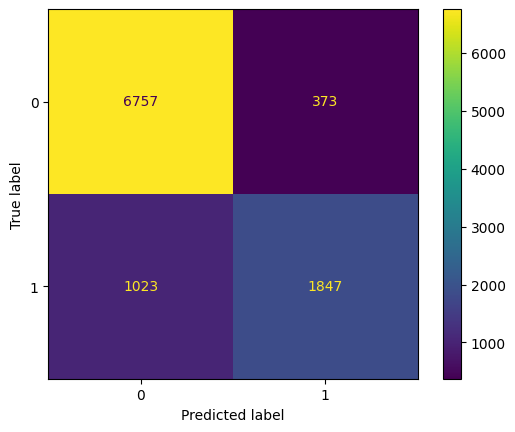

In [59]:
# Confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print(classification_report(y_test, y_pred))

### Simple Model with gridsearch and without data balancing

In [60]:
# # Parameter for the grid
# params = {'max_depth': list(range(6,13)),
#           'min_samples_split': list(range(2,9,2)),
#           'min_samples_leaf': list(range(1,5)),
#           'criterion' : ['gini', 'entropy', 'log_loss'],
#           'splitter' : ['best']}

# # estimator - classifier
# dt_model = DecisionTreeClassifier(random_state = 42)

# # setup the grid search
# grid_search = GridSearchCV(estimator = dt_model,
#                            param_grid = params,
#                            cv = 5,
#                            n_jobs = -1,
#                            verbose = 4)

# # fit the gridsearch model to the data
# grid_search.fit(x_train, y_train)

In [61]:
# # Display the best param and the score
# print('Best Parameters from the grid search are:', grid_search.best_params_)
# print('Score for the best params:', round(grid_search.best_score_*100, 2), '%')

In [62]:
# # Building the final model with best parameters
# best_params = grid_search.best_params_
# final_dt_model = DecisionTreeClassifier(**best_params, random_state = 42)

# # Fit the data onto the model
# final_dt_model.fit(x_train, y_train)
# print('Training Score:', round(final_dt_model.score(x_train, y_train)*100, 2), '%')

# #Test Prediction
# y_pred_final = final_dt_model.predict(x_test)

# #Accuracy score
# print(f'Testing Score: {round((accuracy_score(y_test, y_pred_final))*100, 2)}%')
# print(f'Precision Score: {round((precision_score(y_test, y_pred_final, pos_label = 1))*100, 2)}%')
# print(f'Recall Score: {round((recall_score(y_test, y_pred_final, pos_label = 1))*100, 2)}%')

In [63]:
# Confusion Matrix
# cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
# print(classification_report(y_test, y_pred_final))

## Uisng Stratification

In [74]:
# Dependecy split
x = cleaned_df.drop(['Churned'], axis = 1)
y = cleaned_df[['Churned']]

# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.2, stratify = y)

# Label encoding 

#Using categorical columns for encoding
cat_cols = [cols for cols in x_train.columns if x_train[cols].dtype == 'O']

#Label encoder
encoders = {}

#Apply label encoding on x_train columns
for col in cat_cols:
    encoders[col] = LabelEncoder()
    x_train[col] = encoders[col].fit_transform(x_train[col])

#Apply label encoding on x_test columns
for col in cat_cols:
    x_test[col] = encoders[col].transform(x_test[col])

#### Simple DT model without tuning

Training Score: 87.83 %
Testing Score: 85.74 %
Precision Score: 82.11 %
Recall Score: 64.78 %
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      7110
           1       0.82      0.65      0.72      2890

    accuracy                           0.86     10000
   macro avg       0.84      0.80      0.81     10000
weighted avg       0.85      0.86      0.85     10000



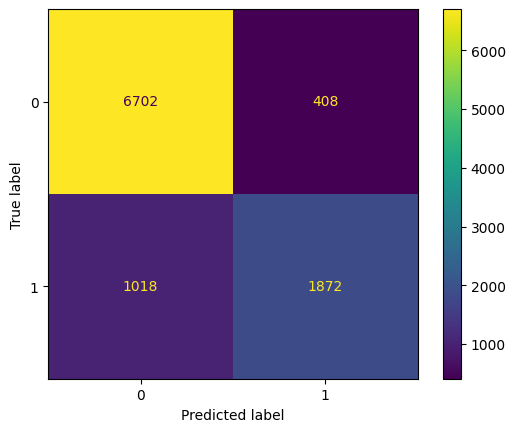

In [75]:
# Buliding a simple decision tree model with random parameters
dt_model = DecisionTreeClassifier(max_depth = 8, random_state =  42)
dt_model.fit(x_train, y_train)
print(f'Training Score: {round((dt_model.score(x_train, y_train))*100, 2)} %')

# Test Prediction 
y_pred = dt_model.predict(x_test)


# Metrics
print(f'Testing Score: {round((accuracy_score(y_test, y_pred))*100, 2)} %')
print(f'Precision Score: {round((precision_score(y_test, y_pred, pos_label = 1))*100, 2)} %')
print(f'Recall Score: {round((recall_score(y_test, y_pred, pos_label = 1))*100, 2)} %')


# Confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print(classification_report(y_test, y_pred))

#### Simple DT model with tuning

In [76]:
# # Parameter for the grid
# params = {'max_depth': list(range(6,13)),
#           'min_samples_split': list(range(2,9,2)),
#           'min_samples_leaf': list(range(1,5)),
#           'criterion' : ['gini', 'entropy', 'log_loss'],
#           'splitter' : ['best']}

# # estimator - classifier
# dt_model = DecisionTreeClassifier(random_state = 42)

# # setup the grid search
# grid_search = GridSearchCV(estimator = dt_model,
#                            param_grid = params,
#                            cv = 5,
#                            n_jobs = -1,
#                            verbose = 4)

# # fit the gridsearch model to the data
# grid_search.fit(x_train, y_train)


# # Display the best param and the score
# print('\nBest Parameters from the grid search are:', grid_search.best_params_)
# print('Score for the best params:', round(grid_search.best_score_*100, 2), '%')

# # Building the final model with best parameters
# best_params = grid_search.best_params_
# final_dt_model = DecisionTreeClassifier(**best_params, random_state = 42)

# # Fit the data onto the model
# final_dt_model.fit(x_train, y_train)
# print('Training Score:', round(final_dt_model.score(x_train, y_train)*100, 2), '%')

# #Test Prediction
# y_pred_final = final_dt_model.predict(x_test)

# #Accuracy score
# print(f'\nTesting Score: {round((accuracy_score(y_test, y_pred_final))*100, 2)}%')
# print(f'Precision Score: {round((precision_score(y_test, y_pred_final, pos_label = 1))*100, 2)}%')
# print(f'Recall Score: {round((recall_score(y_test, y_pred_final, pos_label = 1))*100, 2)}%')

In [77]:
# Confusion Matrix
# cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
# print(classification_report(y_test, y_pred_final))

### Observation from DT Model: 

Although Model 2 shows marginally better churn precision and recall, it was evaluated on a non-stratified split, making its performance less reliable.

Model 4, which uses both hyperparameter tuning and stratified sampling, provides the most trustworthy and production-ready performance.

Hyperparameter tuning improved the Decision Tree slightly,
but the real gains will come from ensemble models like Random Forest.

### Simple RF Model without gridsearch

Training Score: 100.0 %
Testing Score: 88.57 %
Precision Score: 86.69 %
Recall Score: 71.42 %

               precision    recall  f1-score   support

           0       0.89      0.96      0.92      7110
           1       0.87      0.71      0.78      2890

    accuracy                           0.89     10000
   macro avg       0.88      0.83      0.85     10000
weighted avg       0.88      0.89      0.88     10000



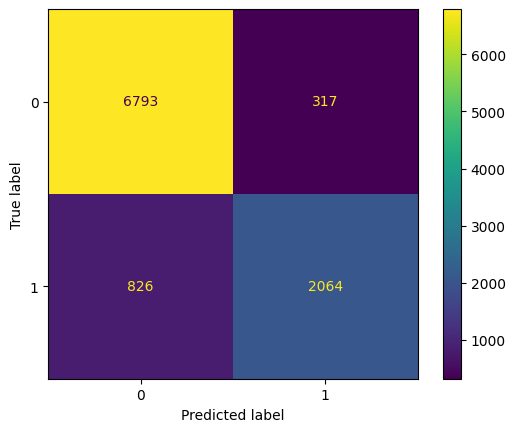

In [79]:
# Buliding a simple decision tree model with random parameters
rf_model = RandomForestClassifier(random_state =  42)
rf_model.fit(x_train, y_train)
print(f'Training Score: {round((rf_model.score(x_train, y_train))*100, 2)} %')

# Test Prediction 
y_pred = rf_model.predict(x_test)


# Metrics
print(f'Testing Score: {round((accuracy_score(y_test, y_pred))*100, 2)} %')
print(f'Precision Score: {round((precision_score(y_test, y_pred, pos_label = 1))*100, 2)} %')
print(f'Recall Score: {round((recall_score(y_test, y_pred, pos_label = 1))*100, 2)} %')


# Confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print('\n', classification_report(y_test, y_pred))

### RF Model with gridsearch

In [82]:
# Hyper parameter tuning for random forest

# Start Timer
start_time = time.time()

# Initialize Random Forest Classifier
rf_cv = RandomForestClassifier(random_state=42)  # random_state ensures reproducibility

# Set Up GridSearchCV for Hyperparameter Tuning
hyper_fit = GridSearchCV(
    estimator=rf_cv,       # the model to tune
    param_grid={           # dictionary of hyperparameters to try
        'criterion': ['gini', 'entropy'],       # split quality metrics
        'bootstrap': [True, False],            # use bootstrap samples or not
        'max_features': ['sqrt', 'log2', None, 'auto']  # number of features considered at each split
    },
    cv=5,                  # 5-fold cross-validation
    n_jobs=-1              # use all CPU cores for parallel processing
)

# Fit GridSearchCV to the Training Data
hyper_fit.fit(x_train, y_train)  # trains and evaluates all combinations using CV

# Display the Best Hyperparameters Found
print('Best Parameters from the grid search:', hyper_fit.best_params_)

# End Timer and Show Time Taken
end_time = time.time()
print('Time taken for grid search:', round(end_time - start_time, 2), 's')

Best Parameters from the grid search: {'bootstrap': True, 'criterion': 'entropy', 'max_features': None}
Time taken for grid search: 863.86 s


In [92]:
# Setting the best parameter to the model
best_params = hyper_fit.best_params_
final_model = RandomForestClassifier(**best_params, random_state = 42)

In [84]:
# OOB - Out of bag
final_model.set_params(oob_score = True, warm_start = True, n_jobs = -1)

# Number of trees
min_trees, max_trees = 15, 700

# Error rate
error_rate = {}   # tree_no : error_rate

# Iteration to find the error rate of the trees
for tree in range(min_trees, max_trees):
    final_model.set_params(n_estimators = tree)
    final_model.fit(x_train, y_train)
    oob_error = 1 - final_model.oob_score_
    error_rate[tree] = oob_error

In [93]:
# Convert the dictionary to pandas series
oob_data = pd.Series(error_rate)
oob_data

15     0.131150
16     0.129175
17     0.127950
18     0.126275
19     0.125050
20     0.124900
21     0.124075
22     0.123250
23     0.122900
24     0.122675
25     0.122525
26     0.121850
27     0.121650
28     0.120700
29     0.120600
30     0.119700
31     0.119175
32     0.119050
33     0.118450
34     0.117950
35     0.117525
36     0.117100
37     0.117550
38     0.117175
39     0.117675
40     0.116925
41     0.116750
42     0.116275
43     0.115525
44     0.115525
45     0.115450
46     0.115425
47     0.115025
48     0.115075
49     0.114800
50     0.114825
51     0.114475
52     0.114350
53     0.114150
54     0.113800
55     0.113800
56     0.113875
57     0.113425
58     0.113600
59     0.113750
60     0.113475
61     0.113650
62     0.113600
63     0.113175
64     0.113025
65     0.113400
66     0.113000
67     0.112825
68     0.112900
69     0.112825
70     0.112200
71     0.112275
72     0.112625
73     0.112350
74     0.112175
75     0.111850
76     0.112100
77     0

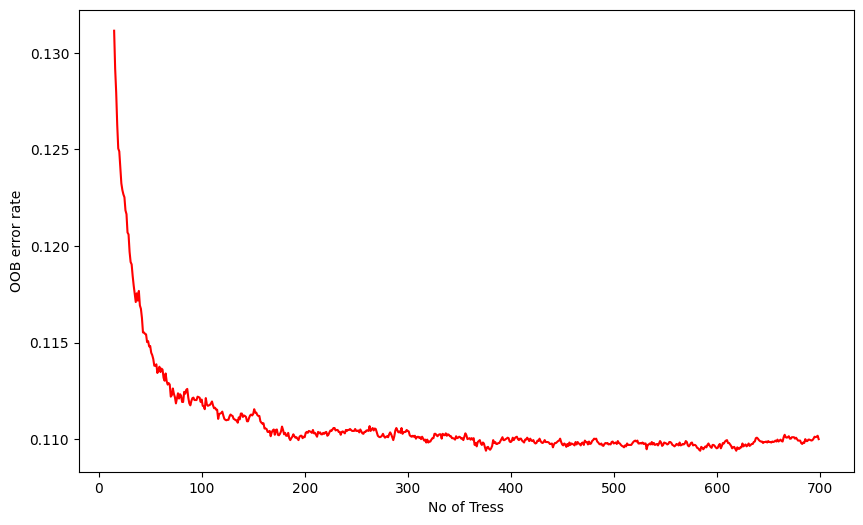

In [94]:
# plot the oob against the number of trees
plt.figure(figsize=(10,6))
oob_data.plot(kind = 'line', color = 'r')
plt.xlabel('No of Tress')
plt.ylabel('OOB error rate')
# plt.axhline(0.045226, color = 'b', ls = '--')
# plt.axhline(0.047739, color = 'b', ls = '--')
# plt.axvline(215, color = 'b', ls = '--')
# plt.axvline(306, color = 'b', ls = '--')
plt.show()

In [95]:
# Check the final model params before fitting the estimators
print(final_model.get_params)

<bound method BaseEstimator.get_params of RandomForestClassifier(criterion='entropy', max_features=None, random_state=42)>


<bound method BaseEstimator.get_params of RandomForestClassifier(criterion='entropy', max_features=None, n_estimators=250,
                       random_state=42)>

Training Score: 100.0 %
Testing Score: 89.17 %
Classification Report:

               precision    recall  f1-score   support

           0       0.90      0.95      0.93      7110
           1       0.86      0.74      0.80      2890

    accuracy                           0.89     10000
   macro avg       0.88      0.85      0.86     10000
weighted avg       0.89      0.89      0.89     10000



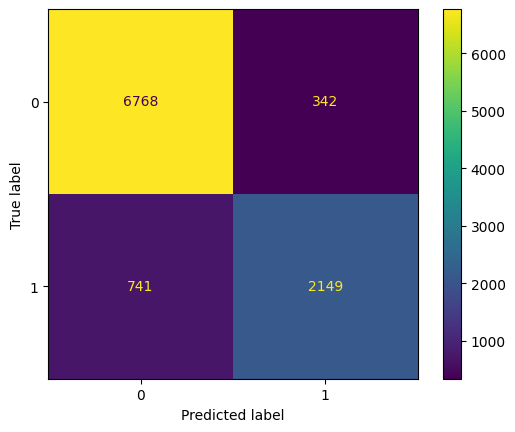

In [96]:
# Refining the trees via OOB
final_model.set_params(n_estimators=250, warm_start=False, oob_score=False, random_state=42)

# Final model parameters
print(final_model.get_params)

# Model training
final_model.fit(x_train, y_train)

# Training score
print('\nTraining Score:', round(final_model.score(x_train, y_train)*100, 2), '%')

# Predictions
y_pred = final_model.predict(x_test)

# Metrics
print('Testing Score:', round(accuracy_score(y_test, y_pred)*100, 2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print('Classification Report:\n\n', classification_report(y_test, y_pred))

In [97]:
# Finding feature importances from the final model
importances = final_model.feature_importances_
importances

array([0.06186047, 0.00393071, 0.01024434, 0.02081956, 0.01287453,
       0.01974203, 0.02138348, 0.01642266, 0.01998781, 0.0127646 ,
       0.07304462, 0.08723706, 0.06152453, 0.09208893, 0.0319724 ,
       0.03018803, 0.06374149, 0.01085081, 0.02163056, 0.02086704,
       0.00858681, 0.02988085, 0.02643704, 0.01462887, 0.05441876,
       0.00043486, 0.00110456, 0.0197727 , 0.11443079, 0.00060265,
       0.03566419, 0.00086228])

In [98]:
# Index of the above array
indx = np.argsort(importances)
indx

array([25, 29, 31, 26,  1, 20,  2, 17,  9,  4, 23,  7,  5, 27,  8,  3, 19,
        6, 18, 22, 21, 15, 14, 30, 24, 12,  0, 16, 10, 11, 13, 28])

In [99]:
# Finding feature names
name_indx = list(x.columns)
name_indx

['Age',
 'Gender',
 'Country',
 'City',
 'Membership_Years',
 'Login_Frequency',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Average_Order_Value',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Lifetime_Value',
 'Credit_Balance',
 'Signup_Quarter',
 'engagement_score',
 'low_engagement_flag',
 'inactive_flag',
 'engagement_recency_risk',
 'friction_score',
 'high_friction_flag',
 'loyalty_score',
 'low_loyalty_flag']

In [100]:
# Create DataFrame with Importances and Column Index
impurity_df = pd.DataFrame({
    'mean_impurity': importances,   # importance values from the model
    'column_index': indx            # indices of features sorted
})

# Map Column Index to Column Names
impurity_df['column_name'] = impurity_df['column_index'].apply(lambda x: name_indx[x])  # lambda function is used to map each index to its corresponding feature name    

# Select Only Relevant Columns
impurity_df = impurity_df[['column_name', 'mean_impurity']]  # keep only feature names and importance

# Sort Features by Importance (Descending)
impurity_df = impurity_df.sort_values(by='mean_impurity', ascending=False)  
# most important features appear at the top

# Reset Index
impurity_df = impurity_df.reset_index(drop=True)  # reset index after sorting to have sequential indices

# Calculate Percentage Importance
impurity_df['percentage_impurity'] = round(impurity_df['mean_impurity'] * 100, 3)  # convert importance to percentage and round to 3 decimals

# Calculate Cumulative Importance
impurity_df['cum_impurity'] = impurity_df['percentage_impurity'].cumsum()  # cumulative sum to see total contribution of top features

# Display the DataFrame
impurity_df

,column_name,mean_impurity,percentage_impurity,cum_impurity
0,Total_Purchases,0.114431,11.443,11.443
1,engagement_recency_risk,0.092089,9.209,20.652
2,Pages_Per_Session,0.087237,8.724,29.376
3,Signup_Quarter,0.073045,7.304,36.680
4,Mobile_App_Usage,0.063741,6.374,43.054
5,low_engagement_flag,0.061860,6.186,49.240
6,Login_Frequency,0.061525,6.152,55.392
7,engagement_score,0.054419,5.442,60.834
8,Discount_Usage_Rate,0.035664,3.566,64.400
9,Cart_Abandonment_Rate,0.031972,3.197,67.597


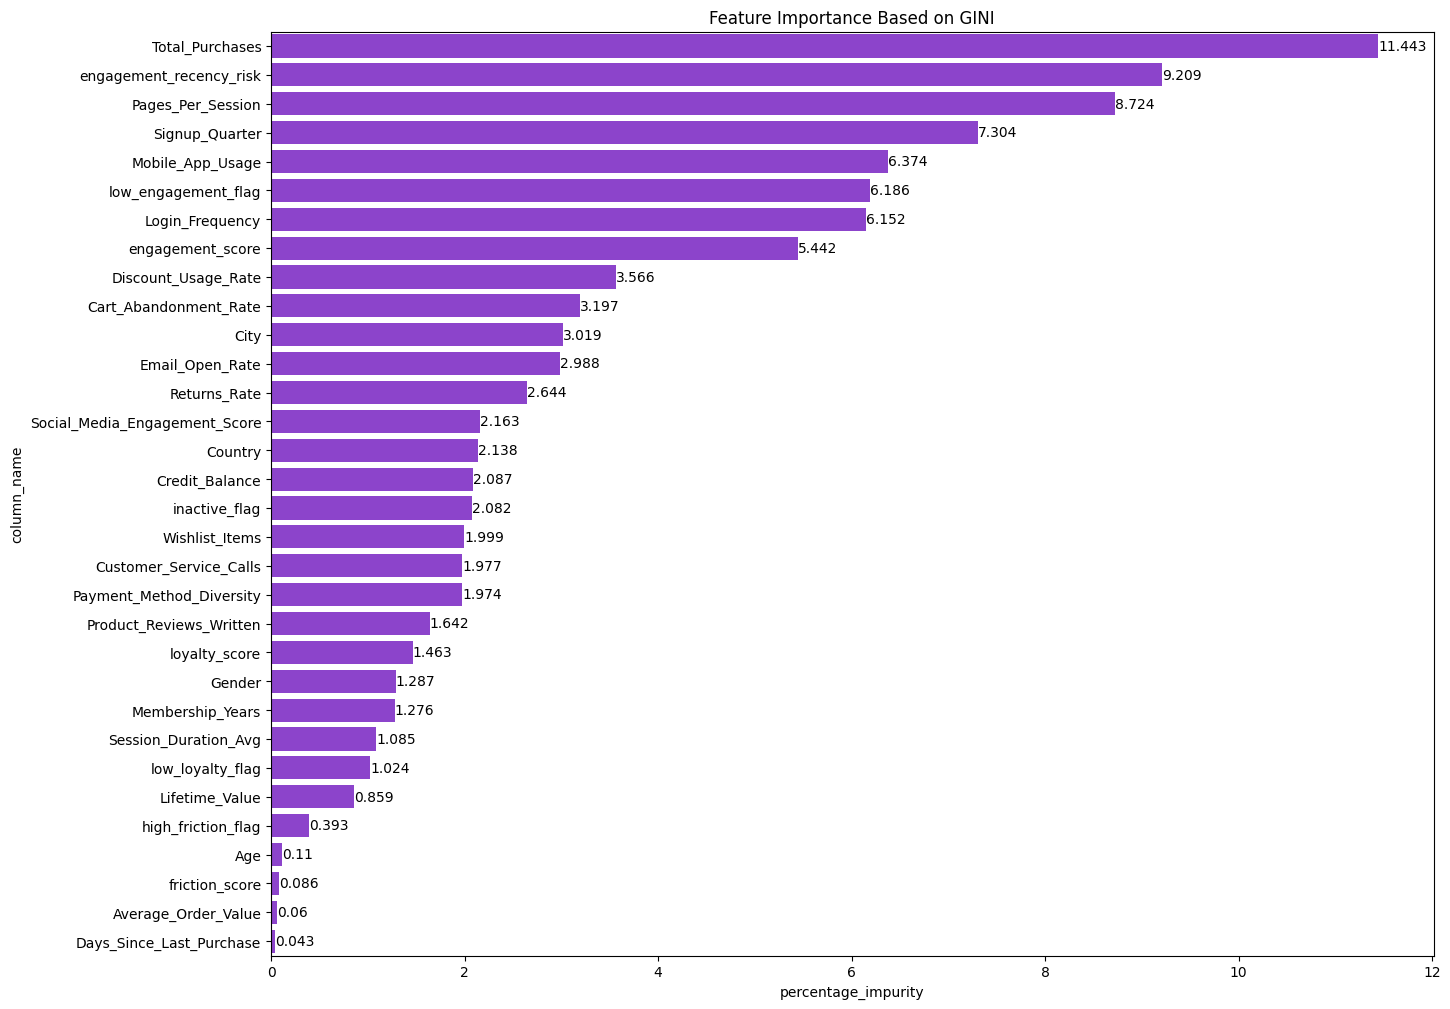

In [101]:
# Feature importance graph with horizontal bars
plt.figure(figsize=(15,12))
ax = sns.barplot(data = impurity_df, y = 'column_name', x = 'percentage_impurity', color='#8e2de2')
ax.bar_label(ax.containers[0])
plt.title('Feature Importance Based on GINI')
plt.show()

In [102]:
# Filtering the columns with 90% mean impurity
final_columns = list(impurity_df[impurity_df['cum_impurity'] <= 90].column_name)

# Filtering the x_train and x_test data for above columns
x_train_filtered = x_train[final_columns]
x_test_filtered = x_test[final_columns]


Training Score: 100.0 %
Testing Score: 80.52 %
Classification Report:

               precision    recall  f1-score   support

           0       0.83      0.92      0.87      7110
           1       0.73      0.52      0.61      2890

    accuracy                           0.81     10000
   macro avg       0.78      0.72      0.74     10000
weighted avg       0.80      0.81      0.79     10000



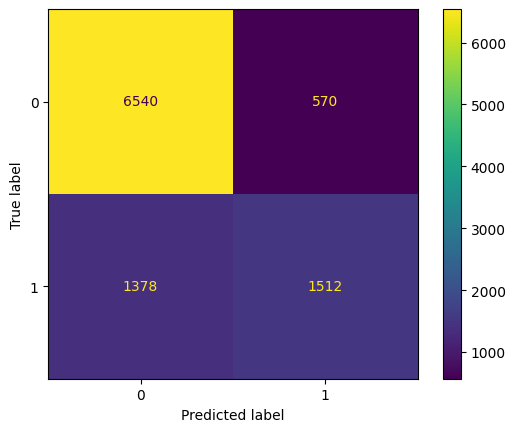

In [103]:
# Optimized model
final_params = final_model.get_params()
opt_model = RandomForestClassifier(**final_params)

# Training the data
opt_model.fit(x_train_filtered, y_train)

# Training score
print('\nTraining Score:', round(opt_model.score(x_train_filtered, y_train)*100, 2), '%')

# Predictions
opt_y_pred = opt_model.predict(x_test_filtered)

# Metrics
print('Testing Score:', round(accuracy_score(y_test, opt_y_pred)*100, 2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, opt_y_pred)
print('Classification Report:\n\n', classification_report(y_test, opt_y_pred))

## Conclusion

Feature importance–based pruning was explored as a potential step to simplify the model and improve generalization. However, this approach resulted in degraded performance across key churn metrics, particularly recall and false negatives. Feature importance pruning did not improve performance because the engineered features already capture stable behavioral patterns, and Random Forest benefits from multiple correlated signals rather than a reduced feature set.

Given these observations, feature importance was retained for interpretation only, and not used for feature elimination.

After extensive exploratory analysis, data cleaning, feature engineering, and model experimentation, the Random Forest classifier has emerged as the best-performing and most stable model for churn prediction at this stage.

The final model uses a stratified train–test split to preserve the original churn distribution and was trained using approximately 250 trees, selected based on Out-of-Bag (OOB) error saturation analysis. This ensured that the model complexity was sufficient for learning stable patterns without unnecessary computational overhead.

In [111]:
# Probabilities for churn class (class = 1)
y_proba = final_model.predict_proba(x_test)[:, 1]

thresholds = np.arange(0.3, 0.61, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    results.append({
        'threshold': t,
        'TP': tp,
        'FN': fn,
        'FP': fp,
        'TN': tn,
        'recall': recall_score(y_test, y_pred_t),
        'precision': precision_score(y_test, y_pred_t),
        'f1': f1_score(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame(results)
threshold_df

,threshold,TP,FN,FP,TN,recall,precision,f1
0,0.30,2410,480,839,6271,0.833910,0.741767,0.785144
1,0.35,2358,532,688,6422,0.815917,0.774130,0.794474
2,0.40,2297,593,545,6565,0.794810,0.808234,0.801465
3,0.45,2223,667,429,6681,0.769204,0.838235,0.802237
4,0.50,2156,734,351,6759,0.746021,0.859992,0.798962
5,0.55,2060,830,276,6834,0.712803,0.881849,0.788366
6,0.60,1954,936,221,6889,0.676125,0.898391,0.771570


Classification Report:

               precision    recall  f1-score   support

           0       0.92      0.92      0.92      7110
           1       0.81      0.79      0.80      2890

    accuracy                           0.89     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.89      0.89      0.89     10000



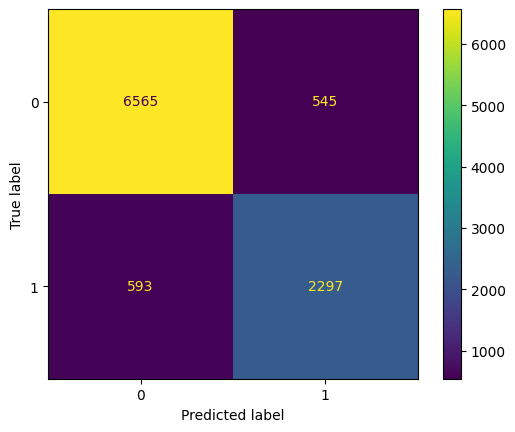

In [113]:
# Plot the final confusion matrix

final_threshold = 0.40
y_pred_final = (y_proba >= final_threshold).astype(int)

cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)
print('Classification Report:\n\n', classification_report(y_test, y_pred_final))

## Business Impact Explanation – Churn Prediction Model

### Business Context
Customer churn directly impacts revenue, customer lifetime value, and acquisition costs. From a business standpoint, **failing to identify a customer who is likely to churn (False Negative)** is significantly more costly than **incorrectly flagging a loyal customer as at risk (False Positive)**.

---

### Baseline Model Behavior (Threshold = 0.50)
Under the default classification threshold:
- **Missed churners (False Negatives): 734**
- These customers would exit the platform without any proactive retention effort
- This leads to:
  - Direct revenue loss
  - Missed retention opportunities
  - Increased future acquisition costs

---

### Optimized Model Behavior (Threshold = 0.40)
After threshold tuning:
- **Missed churners (False Negatives): 593**
- **141 additional churn-prone customers are identified early**
- This represents an approximate **19% reduction in missed churners**

---

### Business Value Created

#### 1. Increased Retention Opportunities
Lowering the threshold allows the model to:
- Flag more customers who are genuinely at risk
- Enable proactive interventions such as:
  - Personalized offers
  - Targeted communication campaigns
  - Customer support outreach

Even retaining a small percentage of these additional customers results in a **positive return on investment**.

---

#### 2. Controlled Trade-Off: False Positives
- False positives increased from **351 to 545**
- These customers receive retention outreach despite not being at risk

From a business perspective:
- The cost of outreach (emails, discounts, CRM actions) is **low**
- This cost is substantially lower than the cost of losing a customer

---

#### 3. Cost-Based Justification

| Error Type | Business Impact |
|----------|-----------------|
| False Negative (Missed Churner) | High – lost revenue and increased acquisition cost |
| False Positive (Unnecessary Outreach) | Low – marketing and operational cost |

The optimized model intentionally prioritizes **revenue protection over perfect precision**.

---

### Final Business Justification
Lowering the churn classification threshold to **0.40** enables earlier detection of at-risk customers, substantially reducing potential revenue loss while introducing only a marginal increase in operational cost. This trade-off aligns with a **retention-first business strategy**.

---

### Executive Summary
> *By optimizing the classification threshold, the churn prediction model reduces missed churners by nearly 20%, allowing for proactive retention actions and improved customer lifetime value with minimal additional operational cost.*